# Australian CPI Forecasting EDA

This notebook performs a screening-stage EDA pass over the curated quarterly macro table for SARIMA/SARIMAX/LSTM modelling. Statistical screens are treated as indicative only because the sample is small and several predictors have early missingness. Forecast-origin availability is represented as an explicit assumption set, not as a fact derived from the curated schema.

In [29]:
from pathlib import Path
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.platform_validation import validate_curated_with_pandera
from src.validation import validate_curated_dataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = ROOT / 'data' / 'curated' / 'quarterly_macro_features.csv'
AVAILABILITY_PATH = ROOT / 'data' / 'metadata' / 'series_availability.csv'
TARGET = 'cpi_yoy'
MAX_LAG = 4
SIGNAL_P_THRESHOLD = 0.10
SIGNAL_CORR_THRESHOLD = 0.20
MATERIAL_MISSING_THRESHOLD = 0.20
VIF_THRESHOLD = 10.0

## 1. Data Integrity Checks

In [30]:
df = pd.read_csv(DATA_PATH)
df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q')
df['quarter_start'] = df['quarter_period'].dt.to_timestamp(how='start')
df = df.sort_values('quarter_period').reset_index(drop=True)

# src.features owns these rate-change transforms for future curated rebuilds.
# Keep this compatibility block so the current checked-in curated CSV can still
# execute before the generated dataset is refreshed. Rate levels are percentages,
# so differences are percentage-point moves rather than proportional log changes.
RATE_CHANGE_LAG_MAP = {
    'cash_rate': [1],
    'unemployment_rate': [1, 2],
}
for source_col, lags in RATE_CHANGE_LAG_MAP.items():
    if source_col not in df:
        continue
    change_col = f'{source_col}_change'
    df[change_col] = df[source_col].diff()
    for lag in lags:
        df[f'{change_col}_lag{lag}'] = df[change_col].shift(lag)

df_model = df.drop(columns=['quarter_period', 'quarter_start'])

schema = pd.DataFrame({'column': df_model.columns, 'dtype': df_model.dtypes.astype(str).values})
display(schema)
display(df_model.head())

validation_records = [record.as_dict() for record in validate_curated_dataset(df_model)]
validation_records.append(validate_curated_with_pandera(df_model).as_dict())
validation_summary = pd.DataFrame(validation_records)
display(validation_summary.head(16))

quarters = df['quarter_period']
expected_quarters = pd.period_range(quarters.min(), quarters.max(), freq='Q')
integrity_summary = pd.DataFrame([
    {'check': 'row_count', 'value': len(df)},
    {'check': 'column_count', 'value': len(df_model.columns)},
    {'check': 'start_quarter', 'value': str(quarters.min())},
    {'check': 'end_quarter', 'value': str(quarters.max())},
    {'check': 'duplicate_quarters', 'value': int(df['quarter'].duplicated().sum())},
    {'check': 'missing_quarters', 'value': int(len(expected_quarters.difference(quarters)))},
    {'check': 'is_sorted', 'value': bool(quarters.is_monotonic_increasing)},
])
display(integrity_summary)

,column,dtype
0,quarter,str
1,cpi_index,float64
2,cpi_qoq,float64
3,cpi_yoy,float64
4,unemployment_rate,float64
5,cash_rate,float64
6,wage_price_index,float64
7,wpi_growth,float64
8,producer_price_index,float64
9,ppi_growth,float64


,quarter,cpi_index,cpi_qoq,cpi_yoy,unemployment_rate,cash_rate,wage_price_index,wpi_growth,producer_price_index,ppi_growth,commodity_price_index,commodity_growth,wti_price,wti_growth,brent_price,brent_growth,aud_usd,aud_usd_change,household_spending,household_spending_growth,inflation_expectations_business,cpi_yoy_lag1,cpi_yoy_lag4,cash_rate_lag1,cash_rate_lag2,cash_rate_lag4,unemployment_rate_lag1,unemployment_rate_lag2,unemployment_rate_lag4,wpi_growth_lag1,wpi_growth_lag2,ppi_growth_lag1,ppi_growth_lag2,commodity_growth_lag1,wti_growth_lag1,brent_growth_lag1,aud_usd_change_lag1,inflation_expectations_business_lag1,cash_rate_change,cash_rate_change_lag1,unemployment_rate_change,unemployment_rate_change_lag1,unemployment_rate_change_lag2
0,1995Q1,44.34,NaN,NaN,8.765343,7.5,NaN,NaN,NaN,NaN,29.996283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995Q2,44.92,1.308074,NaN,8.364921,7.5,NaN,NaN,NaN,NaN,31.011010,3.382842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.39,NaN,NaN,7.5,NaN,NaN,8.765343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.02,0.0,NaN,-0.400421,NaN,NaN
2,1995Q3,45.46,1.202137,NaN,8.370487,7.5,NaN,NaN,NaN,NaN,30.733831,-0.893806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.28,NaN,NaN,7.5,7.5,NaN,8.364921,8.765343,NaN,NaN,NaN,NaN,NaN,3.382842,NaN,NaN,NaN,4.39,0.0,0.0,0.005566,-0.400421,NaN
3,1995Q4,45.81,0.769908,NaN,8.390849,7.5,NaN,NaN,NaN,NaN,30.162208,-1.859915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.58,NaN,NaN,7.5,7.5,NaN,8.370487,8.364921,NaN,NaN,NaN,NaN,NaN,-0.893806,NaN,NaN,NaN,3.28,0.0,0.0,0.020362,0.005566,-0.400421
4,1996Q1,46.00,0.414757,3.743798,8.400038,7.5,NaN,NaN,NaN,NaN,29.976517,-0.615640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.26,NaN,NaN,7.5,7.5,7.5,8.390849,8.370487,8.765343,NaN,NaN,NaN,NaN,-1.859915,NaN,NaN,NaN,2.58,0.0,0.0,0.009189,0.020362,0.005566


,dataset,status,rows,columns,start_date,end_date,missing_values,duplicate_dates,notes
0,curated_quarterly_macro_features,PASS,124,43,1995Q1,2025Q4,699,0,ok
1,curated_column:cpi_index,PASS,124,1,1995Q1,2025Q4,0,0,ok
2,curated_column:cpi_qoq,PASS,123,1,1995Q1,2025Q4,1,0,ok
3,curated_column:cpi_yoy,PASS,120,1,1995Q1,2025Q4,4,0,ok
4,curated_column:unemployment_rate,PASS,124,1,1995Q1,2025Q4,0,0,ok
5,curated_column:cash_rate,PASS,124,1,1995Q1,2025Q4,0,0,ok
6,curated_column:wage_price_index,PASS,114,1,1995Q1,2025Q4,10,0,ok
7,curated_column:wpi_growth,PASS,113,1,1995Q1,2025Q4,11,0,ok
8,curated_column:producer_price_index,PASS,110,1,1995Q1,2025Q4,14,0,ok
9,curated_column:ppi_growth,PASS,109,1,1995Q1,2025Q4,15,0,ok


,check,value
0,row_count,124
1,column_count,43
2,start_quarter,1995Q1
3,end_quarter,2025Q4
4,duplicate_quarters,0
5,missing_quarters,0
6,is_sorted,True


## 2. Missing Values And Coverage

In [31]:
def first_last_non_null_date(frame: pd.DataFrame, column: str) -> tuple[str | None, str | None]:
    mask = frame[column].notna()
    if not mask.any():
        return None, None
    return str(frame.loc[mask, 'quarter_period'].iloc[0]), str(frame.loc[mask, 'quarter_period'].iloc[-1])


def coverage_class(coverage_pct: float) -> str:
    if coverage_pct >= 0.95:
        return 'core_long_sample_candidate'
    if coverage_pct >= 0.80:
        return 'shorter_sample_candidate'
    if coverage_pct >= 0.50:
        return 'limited_sample_candidate'
    return 'exclude_low_coverage'


sample_start = str(df['quarter_period'].min())
coverage_rows = []
for column in df_model.columns:
    if column == 'quarter':
        continue
    first_non_null, last_non_null = first_last_non_null_date(df, column)
    missing_count = int(df[column].isna().sum())
    available_observations = int(df[column].notna().sum())
    missing_pct = missing_count / len(df)
    coverage_pct = available_observations / len(df)
    late_start_reduces_sample = first_non_null not in {None, sample_start}
    substantial_missingness = missing_pct >= MATERIAL_MISSING_THRESHOLD
    coverage_rows.append({
        'variable': column,
        'available_observations': available_observations,
        'non_null_rows': available_observations,
        'missing_count': missing_count,
        'missing_pct': missing_pct,
        'coverage_pct': coverage_pct,
        'start_quarter': sample_start,
        'first_non_null': first_non_null,
        'last_non_null': last_non_null,
        'late_start_reduces_estimation_sample': bool(late_start_reduces_sample),
        'substantial_missingness_warning': bool(substantial_missingness),
        # Backward-compatible name used later in the notebook; this now means
        # genuinely substantial missingness, not merely starting after 1995Q1.
        'material_early_missingness': bool(substantial_missingness),
        'coverage_class': coverage_class(coverage_pct),
    })

coverage = pd.DataFrame(coverage_rows).sort_values(['missing_pct', 'variable'], ascending=[False, True])
display(coverage)
display(coverage.loc[coverage['substantial_missingness_warning'], ['variable', 'missing_pct', 'coverage_pct', 'first_non_null', 'last_non_null', 'coverage_class']])

,variable,available_observations,non_null_rows,missing_count,missing_pct,coverage_pct,start_quarter,first_non_null,last_non_null,late_start_reduces_estimation_sample,substantial_missingness_warning,material_early_missingness,coverage_class
18,household_spending_growth,53,53,71,0.572581,0.427419,1995Q1,2012Q4,2025Q4,True,True,True,exclude_low_coverage
17,household_spending,54,54,70,0.564516,0.435484,1995Q1,2012Q3,2025Q4,True,True,True,exclude_low_coverage
35,aud_usd_change_lag1,62,62,62,0.500000,0.500000,1995Q1,2010Q3,2025Q4,True,True,True,limited_sample_candidate
16,aud_usd_change,63,63,61,0.491935,0.508065,1995Q1,2010Q2,2025Q4,True,True,True,limited_sample_candidate
15,aud_usd,64,64,60,0.483871,0.516129,1995Q1,2010Q1,2025Q4,True,True,True,limited_sample_candidate
34,brent_growth_lag1,72,72,52,0.419355,0.580645,1995Q1,2008Q1,2025Q4,True,True,True,limited_sample_candidate
14,brent_growth,73,73,51,0.411290,0.588710,1995Q1,2007Q4,2025Q4,True,True,True,limited_sample_candidate
13,brent_price,74,74,50,0.403226,0.596774,1995Q1,2007Q3,2025Q4,True,True,True,limited_sample_candidate
33,wti_growth_lag1,100,100,24,0.193548,0.806452,1995Q1,2001Q1,2025Q4,True,False,False,shorter_sample_candidate
12,wti_growth,101,101,23,0.185484,0.814516,1995Q1,2000Q4,2025Q4,True,False,False,shorter_sample_candidate


,variable,missing_pct,coverage_pct,first_non_null,last_non_null,coverage_class
18,household_spending_growth,0.572581,0.427419,2012Q4,2025Q4,exclude_low_coverage
17,household_spending,0.564516,0.435484,2012Q3,2025Q4,exclude_low_coverage
35,aud_usd_change_lag1,0.500000,0.500000,2010Q3,2025Q4,limited_sample_candidate
16,aud_usd_change,0.491935,0.508065,2010Q2,2025Q4,limited_sample_candidate
15,aud_usd,0.483871,0.516129,2010Q1,2025Q4,limited_sample_candidate
34,brent_growth_lag1,0.419355,0.580645,2008Q1,2025Q4,limited_sample_candidate
14,brent_growth,0.411290,0.588710,2007Q4,2025Q4,limited_sample_candidate
13,brent_price,0.403226,0.596774,2007Q3,2025Q4,limited_sample_candidate


## 3. CPI Target Inspection

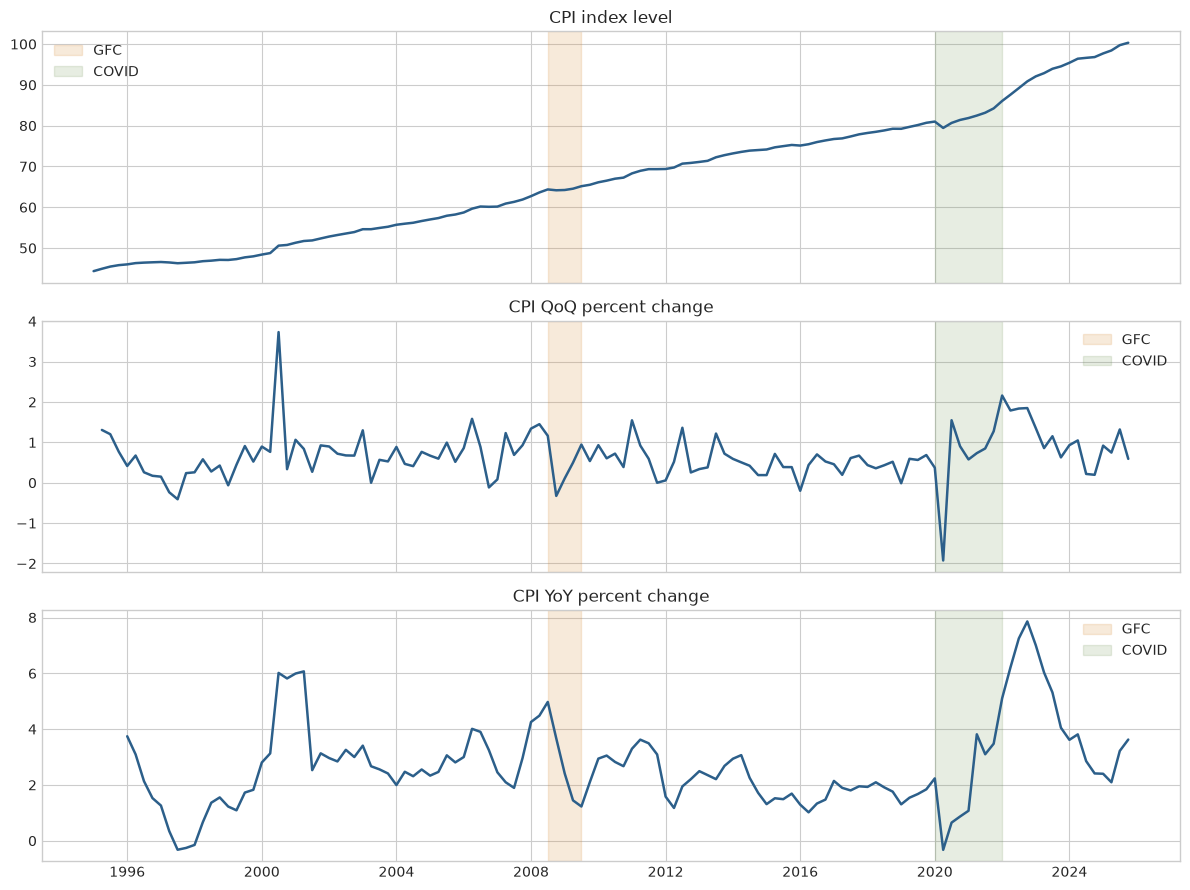

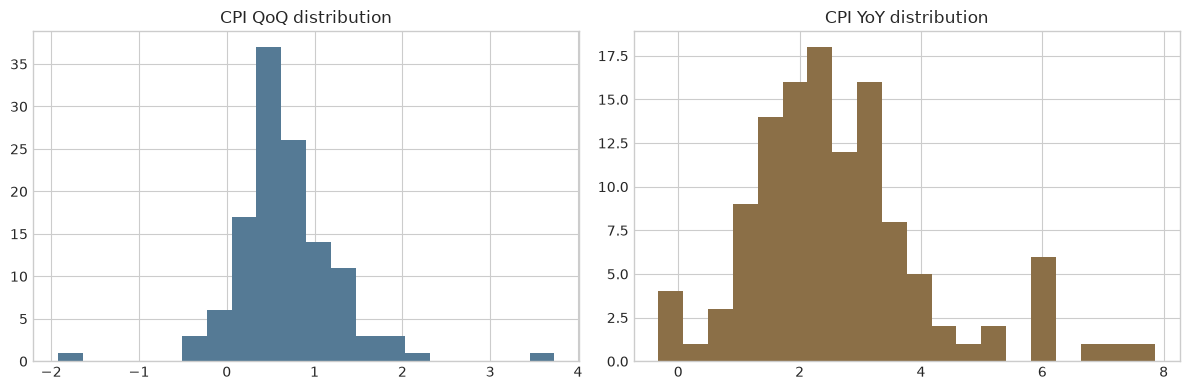

,quarter,metric,value,z_score
0,2000Q3,cpi_qoq,3.731802,5.21
1,2020Q2,cpi_qoq,-1.925926,-4.41
2,2022Q1,cpi_qoq,2.160750,2.54
3,2022Q3,cpi_yoy,7.250210,3.02
4,2022Q4,cpi_yoy,7.859433,3.42
5,2023Q1,cpi_yoy,7.007554,2.86


In [32]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, column, title in zip(axes, ['cpi_index', 'cpi_qoq', 'cpi_yoy'], ['CPI index level', 'CPI QoQ percent change', 'CPI YoY percent change']):
    ax.plot(df['quarter_start'], df[column], color='#2c5f8a', linewidth=1.8)
    ax.set_title(title)
    ax.axvspan(pd.Period('2008Q3', freq='Q').to_timestamp(), pd.Period('2009Q3', freq='Q').to_timestamp(), color='#d88c36', alpha=0.18, label='GFC')
    ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2022Q1', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.16, label='COVID')
    ax.legend(loc='best')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['cpi_qoq'].dropna().hist(ax=axes[0], bins=20, color='#557a95')
axes[0].set_title('CPI QoQ distribution')
df['cpi_yoy'].dropna().hist(ax=axes[1], bins=20, color='#8b6f47')
axes[1].set_title('CPI YoY distribution')
fig.tight_layout()
plt.show()

outlier_rows = []
for column in ['cpi_qoq', 'cpi_yoy']:
    series = df[column]
    z_score = (series - series.mean()) / series.std(ddof=0)
    flagged = df.loc[z_score.abs() >= 2.5, ['quarter', column]].copy()
    flagged['metric'] = column
    flagged['z_score'] = z_score.loc[flagged.index].round(2)
    outlier_rows.append(flagged[['quarter', 'metric', column, 'z_score']].rename(columns={column: 'value'}))
outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame()
display(outliers)

### CPI Seasonal Decomposition And Autocorrelation Diagnostics

These diagnostics extend the CPI target inspection. STL separates the CPI index into trend, quarterly seasonal, and residual components; ACF/PACF plots then show whether CPI inflation and differenced CPI retain serial dependence that later SARIMA/SARIMAX order selection should consider.

The modelling target `cpi_yoy` is already a four-quarter transformation: `CPI_YoY_t = (CPI_t / CPI_{t-4} - 1) * 100`. Adjacent YoY observations share overlapping CPI observations, so persistence in the ACF is partly mechanical and should not be interpreted as purely an autoregressive economic mechanism. Quarterly data also does not automatically imply `D = 1`; seasonal and non-seasonal SARIMA/SARIMAX specifications should be compared with rolling-origin validation.

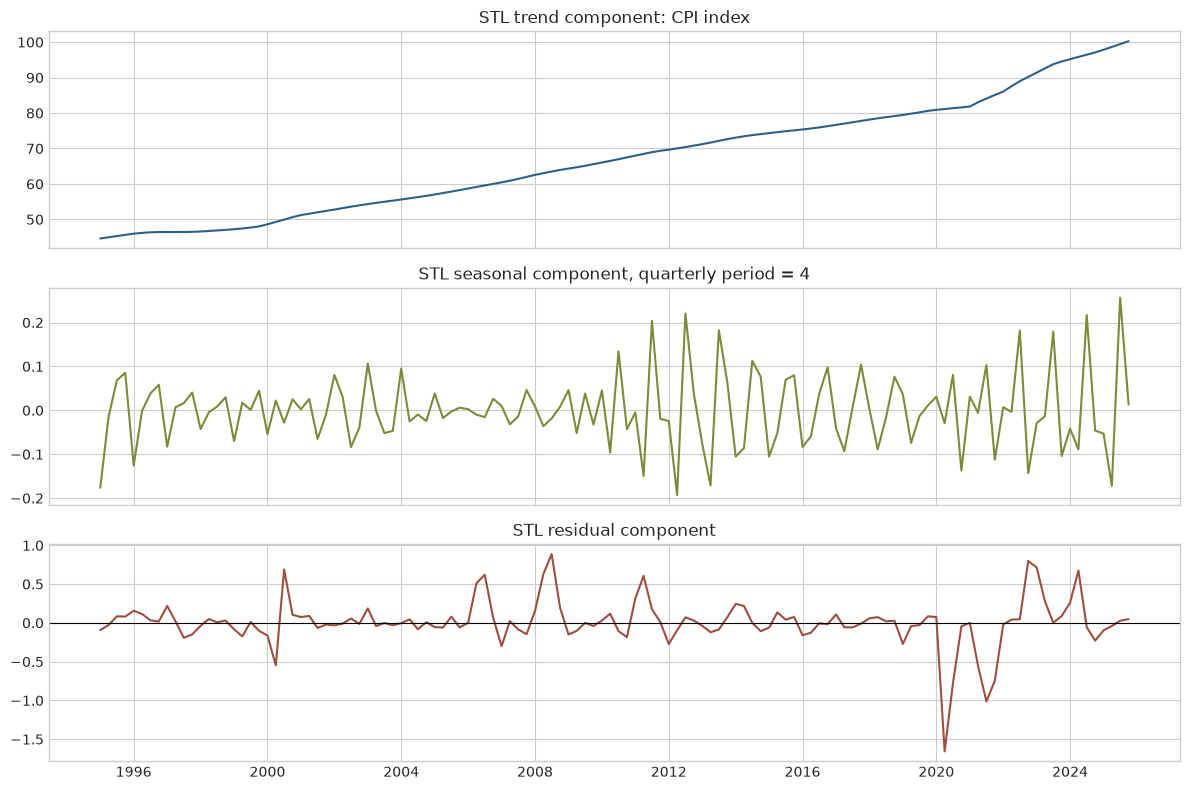

,series,stl_period_quarters,seasonal_strength,trend_strength,n_obs,interpretation
0,cpi_index,4,0.013,1.000,124,Level-series seasonality supports checking qua...
1,cpi_qoq,4,0.055,0.278,123,QoQ seasonality is closer to the inflation-rat...


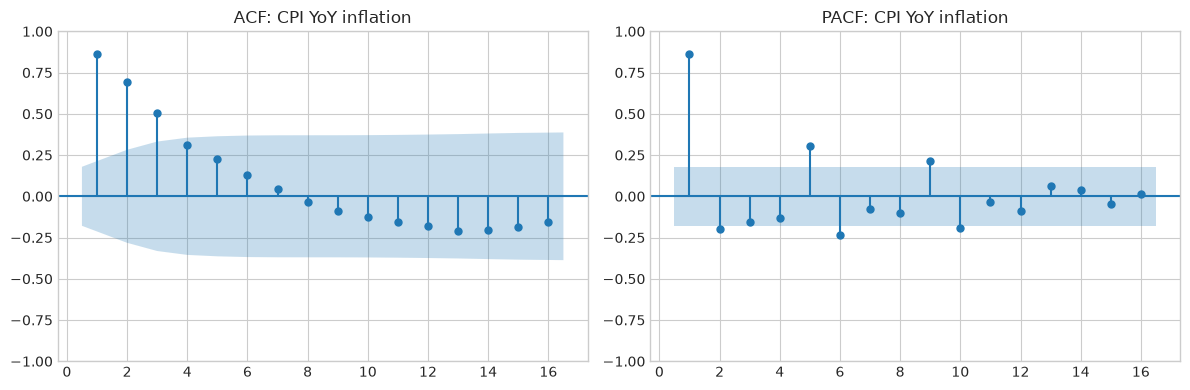

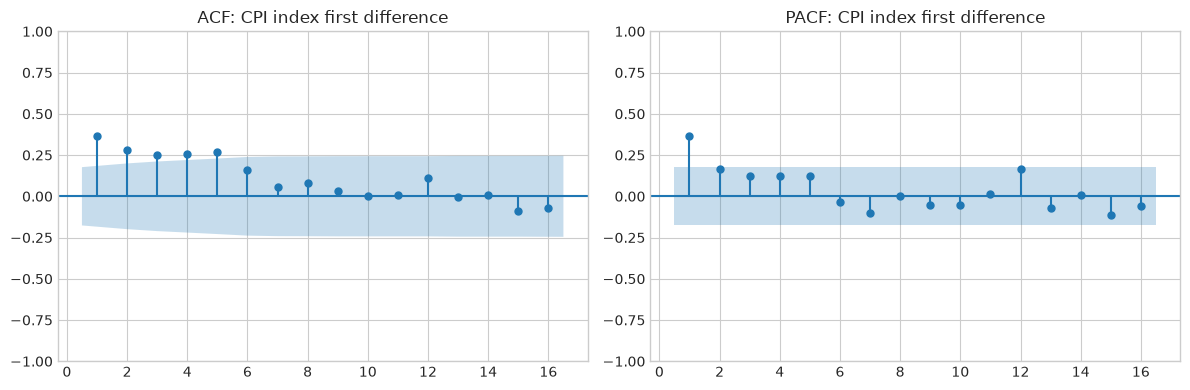

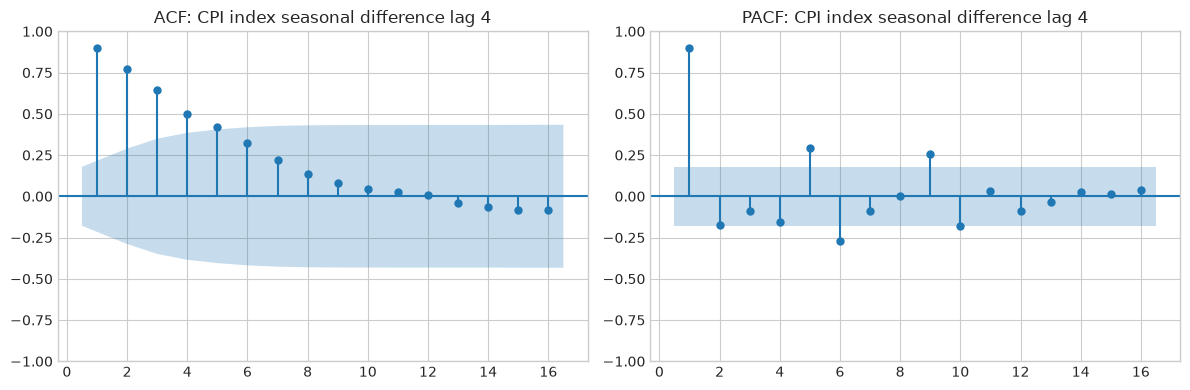

ACF/PACF patterns are visual order-selection aids only. Persistent spikes at seasonal lags support seasonal SARIMA/SARIMAX terms; short-lag decay or cut-offs help motivate candidate AR and MA orders before formal rolling-origin model comparison. The STL strength table reports both CPI level and QoQ inflation so the seasonal read is not inferred from the trending level alone.

In [33]:
def stl_strength_summary(series: pd.Series, label: str) -> dict[str, object]:
    cleaned = series.dropna()
    result = STL(cleaned, period=4, robust=True).fit()
    seasonal_strength = max(0, 1 - np.nanvar(result.resid) / np.nanvar(result.resid + result.seasonal))
    trend_strength = max(0, 1 - np.nanvar(result.resid) / np.nanvar(result.resid + result.trend))
    return {
        'series': label,
        'stl_period_quarters': 4,
        'seasonal_strength': seasonal_strength,
        'trend_strength': trend_strength,
        'n_obs': int(len(cleaned)),
        'stl_result': result,
    }

cpi_stl_series = df.set_index('quarter_start')['cpi_index'].dropna()
stl_result = STL(cpi_stl_series, period=4, robust=True).fit()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(stl_result.trend.index, stl_result.trend, color='#2c5f8a')
axes[0].set_title('STL trend component: CPI index')
axes[1].plot(stl_result.seasonal.index, stl_result.seasonal, color='#7a8b3a')
axes[1].set_title('STL seasonal component, quarterly period = 4')
axes[2].plot(stl_result.resid.index, stl_result.resid, color='#9a4f3f')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('STL residual component')
fig.tight_layout()
plt.show()

stl_strength_rows = [
    stl_strength_summary(df.set_index('quarter_start')['cpi_index'], 'cpi_index'),
    stl_strength_summary(df.set_index('quarter_start')['cpi_qoq'], 'cpi_qoq'),
]
seasonality_summary = pd.DataFrame([
    {key: value for key, value in row.items() if key != 'stl_result'}
    for row in stl_strength_rows
])
seasonality_summary['interpretation'] = np.where(
    seasonality_summary['series'].eq('cpi_index'),
    'Level-series seasonality supports checking quarterly seasonal terms, but model transforms still matter.',
    'QoQ seasonality is closer to the inflation-rate series used in differenced SARIMA/SARIMAX diagnostics.',
)
display(seasonality_summary.round(3))

acf_pacf_series = {
    'CPI YoY inflation': df.set_index('quarter_start')['cpi_yoy'].dropna(),
    'CPI index first difference': df.set_index('quarter_start')['cpi_index'].diff().dropna(),
    'CPI index seasonal difference lag 4': df.set_index('quarter_start')['cpi_index'].diff(4).dropna(),
}

for title, series in acf_pacf_series.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    safe_lags = min(16, max(1, len(series) // 2 - 1))
    plot_acf(series, lags=safe_lags, ax=axes[0], zero=False)
    plot_pacf(series, lags=safe_lags, ax=axes[1], zero=False, method='ywm')
    axes[0].set_title(f'ACF: {title}')
    axes[1].set_title(f'PACF: {title}')
    fig.tight_layout()
    plt.show()

display(Markdown('ACF/PACF patterns are visual order-selection aids only. Persistent spikes at seasonal lags support seasonal SARIMA/SARIMAX terms; short-lag decay or cut-offs help motivate candidate AR and MA orders before formal rolling-origin model comparison. The STL strength table reports both CPI level and QoQ inflation so the seasonal read is not inferred from the trending level alone.'))

## 4. External Variable Inspection

These plots z-score the raw curated predictor columns against CPI YoY for visual inspection only. Use the stationarity-aware CCF and Granger tables below for correlation evidence.

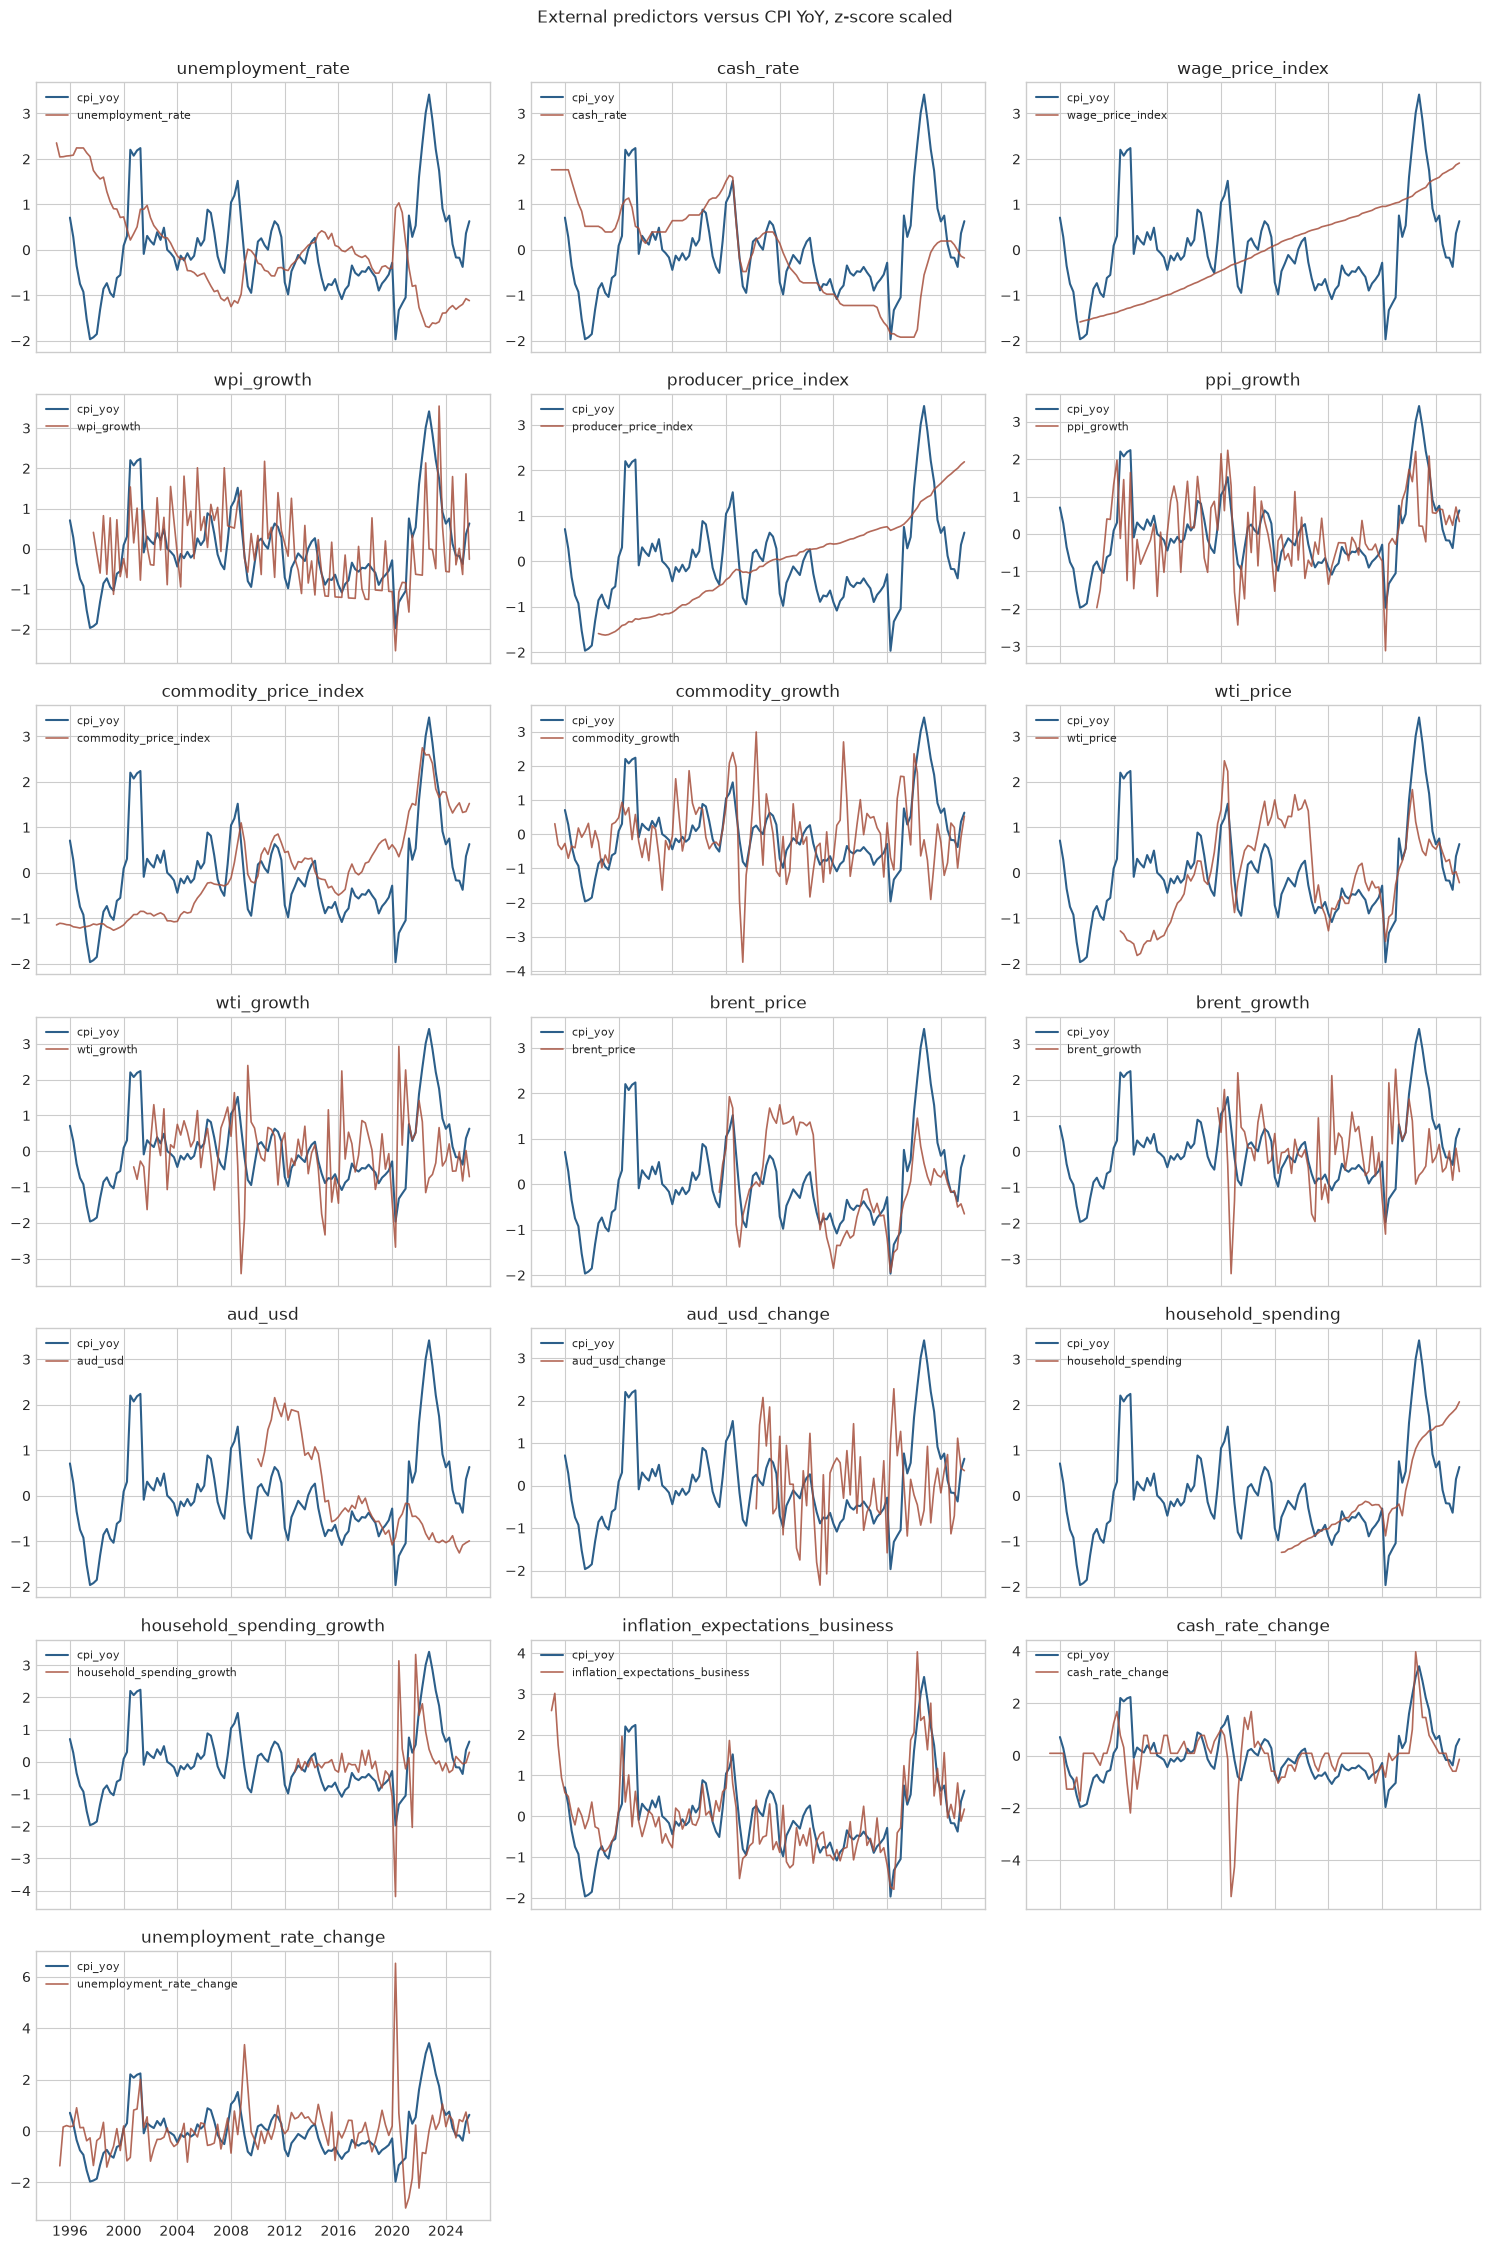

,external_base_variable
0,unemployment_rate
1,cash_rate
2,wage_price_index
3,wpi_growth
4,producer_price_index
5,ppi_growth
6,commodity_price_index
7,commodity_growth
8,wti_price
9,wti_growth


,lagged_feature_from_src_features
0,cash_rate_lag1
1,cash_rate_lag2
2,cash_rate_lag4
3,unemployment_rate_lag1
4,unemployment_rate_lag2
5,unemployment_rate_lag4
6,wpi_growth_lag1
7,wpi_growth_lag2
8,ppi_growth_lag1
9,ppi_growth_lag2


In [34]:
EXTERNAL_BASE_COLS = [
    column for column in df_model.columns
    if column not in {'quarter', 'cpi_index', 'cpi_qoq', 'cpi_yoy'} and '_lag' not in column
]
EXTERNAL_LAGGED_FEATURES = [column for column in df_model.columns if '_lag' in column and not column.startswith('cpi_')]

def zscore(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce')
    std = numeric.std(ddof=0)
    if pd.isna(std) or std == 0:
        return numeric * np.nan
    return (numeric - numeric.mean()) / std


n_cols = 3
n_rows = int(np.ceil(len(EXTERNAL_BASE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.2 * n_rows)), sharex=True)
axes = np.array(axes).reshape(-1)
for ax, column in zip(axes, EXTERNAL_BASE_COLS):
    ax.plot(df['quarter_start'], zscore(df[TARGET]), label=TARGET, color='#2c5f8a', linewidth=1.5)
    ax.plot(df['quarter_start'], zscore(df[column]), label=column, color='#a64f3c', linewidth=1.2, alpha=0.85)
    ax.set_title(column)
    ax.legend(fontsize=8)
for ax in axes[len(EXTERNAL_BASE_COLS):]:
    ax.axis('off')
fig.suptitle('External predictors versus CPI YoY, z-score scaled', y=1.002)
fig.tight_layout()
plt.show()

display(pd.DataFrame({'external_base_variable': EXTERNAL_BASE_COLS}))
display(pd.DataFrame({'lagged_feature_from_src_features': EXTERNAL_LAGGED_FEATURES}))

## 5. Stationarity Tests

ADF and KPSS are diagnostics, not an automatic modelling oracle. The conservative rule used here is ADF p-value `< 0.05` together with KPSS p-value `> 0.05`, but economic interpretation still matters. Index/price-level variables can often be represented by log differences, while rate variables such as the cash rate and unemployment rate are usually more meaningful as percentage-point changes. Any `I(2)` result is flagged for caution rather than treated as unquestioned evidence that second differencing must be used.

In [35]:
eda_df = df.set_index('quarter_period')
STATIONARITY_COLS = ['cpi_index', 'cpi_qoq', 'cpi_yoy'] + EXTERNAL_BASE_COLS

def clean_series(column: str) -> pd.Series:
    return pd.to_numeric(eda_df[column], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()


def safe_adf(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(adfuller(series, autolag='AIC')[1])
    except Exception:
        return np.nan


def safe_kpss(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) < 12 or series.nunique() < 3:
        return np.nan
    try:
        return float(kpss(series, regression='c', nlags='auto')[1])
    except Exception:
        return np.nan


def is_growth_or_change_column(column: str) -> bool:
    return column in {'cpi_qoq', 'cpi_yoy'} or column.endswith('_growth') or column.endswith('_change')


RATE_LEVEL_COLUMNS = {'cash_rate', 'unemployment_rate', 'inflation_expectations_business'}

def should_use_log_diff(column: str, series: pd.Series) -> bool:
    return column not in RATE_LEVEL_COLUMNS and not is_growth_or_change_column(column) and len(series) > 0 and float((series > 0).mean()) >= 0.80


def stationarity_variants(column: str, series: pd.Series) -> dict[str, pd.Series]:
    variants = {
        'level': series,
        'diff1': series.diff(),
        'diff2': series.diff().diff(),
    }
    variants['log_diff1'] = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
    return variants


def integration_order_from_tests(row: pd.Series) -> str:
    def stationary(prefix: str) -> bool:
        adf_ok = pd.notna(row[f'{prefix}_adf_p']) and row[f'{prefix}_adf_p'] < 0.05
        kpss_ok = pd.notna(row[f'{prefix}_kpss_p']) and row[f'{prefix}_kpss_p'] > 0.05
        return bool(adf_ok and kpss_ok)
    if stationary('level'):
        return 'I(0)'
    if stationary('diff1') or stationary('log_diff1'):
        return 'I(1)'
    if stationary('diff2'):
        return 'I(2)'
    return 'unclear'


stationarity_rows = []
for column in STATIONARITY_COLS:
    series = clean_series(column)
    row = {'variable': column, 'n_obs': int(len(series))}
    for variant_name, variant_series in stationarity_variants(column, series).items():
        row[f'{variant_name}_adf_p'] = safe_adf(variant_series)
        row[f'{variant_name}_kpss_p'] = safe_kpss(variant_series)
    stationarity_rows.append(row)

stationarity = pd.DataFrame(stationarity_rows)
stationarity['integration_order'] = stationarity.apply(integration_order_from_tests, axis=1)
stationarity['interpretation_note'] = np.select(
    [
        stationarity['variable'].isin(RATE_LEVEL_COLUMNS),
        stationarity['integration_order'].eq('I(2)'),
        stationarity['variable'].str.endswith('_change'),
    ],
    [
        'rate level: prefer percentage-point changes for SARIMAX screening',
        'I(2) diagnostic: verify cautiously before using second differences',
        'rate/growth change feature: already an economically interpretable transform',
    ],
    default='',
)
display(stationarity.round(4))

,variable,n_obs,level_adf_p,level_kpss_p,diff1_adf_p,diff1_kpss_p,diff2_adf_p,diff2_kpss_p,log_diff1_adf_p,log_diff1_kpss_p,integration_order,interpretation_note
0,cpi_index,124,1.0000,0.010,0.0000,0.0183,0.0000,0.1000,0.0000,0.1000,I(1),
1,cpi_qoq,123,0.0000,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
2,cpi_yoy,120,0.0224,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
3,unemployment_rate,124,0.2714,0.010,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(1),rate level: prefer percentage-point changes fo...
4,cash_rate,124,0.1866,0.010,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(1),rate level: prefer percentage-point changes fo...
5,wage_price_index,114,0.9948,0.010,0.3847,0.0187,0.0031,0.1000,0.3866,0.0209,I(2),I(2) diagnostic: verify cautiously before usin...
6,wpi_growth,113,0.3861,0.021,0.0008,0.1000,0.0000,0.1000,NaN,NaN,I(1),
7,producer_price_index,110,0.9954,0.010,0.0004,0.0707,0.0000,0.1000,0.0000,0.1000,I(1),
8,ppi_growth,109,0.0000,0.100,0.0000,0.1000,0.0000,0.1000,NaN,NaN,I(0),
9,commodity_price_index,124,0.7898,0.010,0.0000,0.1000,0.0000,0.1000,0.0000,0.1000,I(1),


## 6. Lead-Lag Correlation Analysis

,variable,lag_quarters,correlation,n_obs,abs_correlation
149,inflation_expectations_business,1,0.7317,120,0.7317
51,ppi_growth,2,0.5524,107,0.5524
42,producer_price_index,2,0.5517,107,0.5517
159,cash_rate_change,2,0.5158,120,0.5158
15,cash_rate,2,0.5158,120,0.5158
142,household_spending_growth,3,0.4893,50,0.4893
133,household_spending,3,0.4762,50,0.4762
95,brent_price,1,0.4711,73,0.4711
106,brent_growth,3,0.3621,70,0.3621
88,wti_growth,3,0.3438,98,0.3438


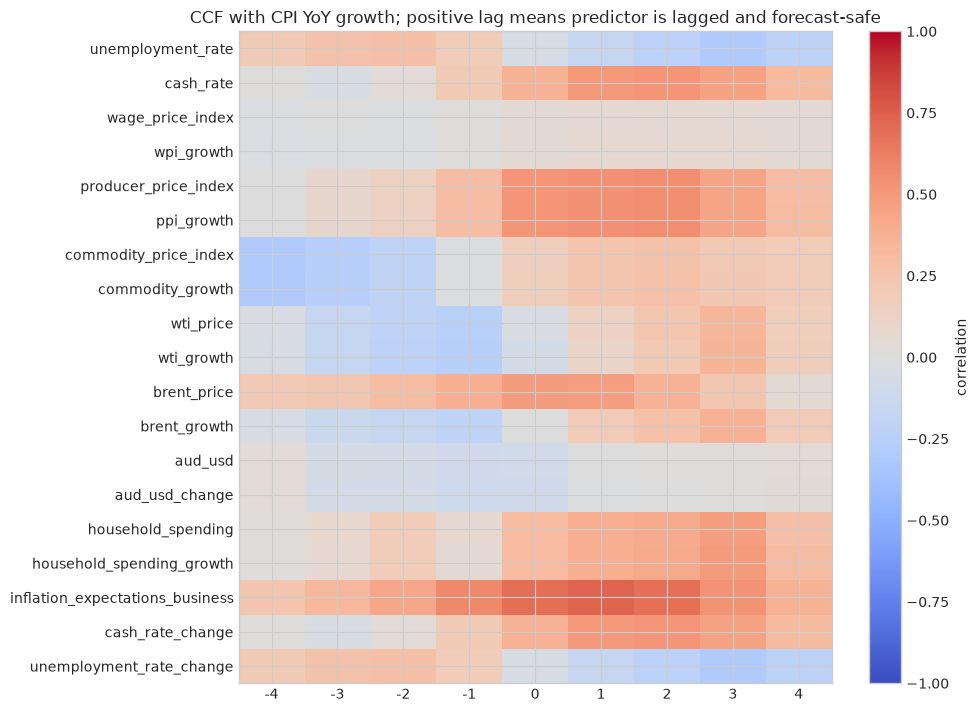

In [36]:
integration_lookup = dict(zip(stationarity['variable'], stationarity['integration_order']))

def stationary_series(column: str) -> pd.Series:
    series = clean_series(column)
    order = integration_lookup.get(column, 'unclear')
    if order == 'I(0)':
        result = series
    elif order == 'I(2)':
        result = series.diff().diff()
    else:
        log_diff = np.log(series.where(series > 0)).diff() if should_use_log_diff(column, series) else pd.Series(dtype='float64')
        result = log_diff if log_diff.notna().sum() >= 12 else series.diff()
    return result.replace([np.inf, -np.inf], np.nan).dropna()


target_stationary = stationary_series(TARGET).rename(TARGET)
ccf_rows = []
for column in EXTERNAL_BASE_COLS:
    x = stationary_series(column).rename(column)
    for lag in range(-MAX_LAG, MAX_LAG + 1):
        aligned = pd.concat([target_stationary, x.shift(lag)], axis=1).dropna()
        corr = aligned[TARGET].corr(aligned[column]) if len(aligned) >= 12 else np.nan
        ccf_rows.append({'variable': column, 'lag_quarters': lag, 'correlation': corr, 'n_obs': len(aligned)})

ccf = pd.DataFrame(ccf_rows)
positive_lag_ccf = ccf.loc[ccf['lag_quarters'] > 0].dropna(subset=['correlation']).copy()
best_predictive_ccf = (
    positive_lag_ccf.assign(abs_correlation=lambda frame: frame['correlation'].abs())
    .sort_values(['variable', 'abs_correlation'], ascending=[True, False])
    .groupby('variable', as_index=False)
    .head(1)
    .sort_values('abs_correlation', ascending=False)
)
display(best_predictive_ccf.round(4))

heatmap_data = ccf.pivot(index='variable', columns='lag_quarters', values='correlation').loc[EXTERNAL_BASE_COLS]
fig, ax = plt.subplots(figsize=(10, max(4, 0.38 * len(EXTERNAL_BASE_COLS))))
image = ax.imshow(heatmap_data, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('CCF with CPI YoY growth; positive lag means predictor is lagged and forecast-safe')
fig.colorbar(image, ax=ax, label='correlation')
fig.tight_layout()
plt.show()

## 7. Granger Causality Screening

Granger tests are retained as predictive screens only. A significant result means past values of a predictor contain incremental predictive information for CPI inflation conditional on past CPI inflation. Granger causality is not structural or economic causality, especially for policy variables such as the RBA cash rate that also respond to inflation.

In [37]:
best_lag_lookup = dict(zip(best_predictive_ccf['variable'], best_predictive_ccf['lag_quarters']))

def granger_screen(variable: str) -> dict[str, object]:
    x = stationary_series(variable).rename(variable)
    data = pd.concat([target_stationary.rename(TARGET), x], axis=1).dropna()
    max_lag = min(MAX_LAG, max(1, len(data) // 10))
    selected_lag = int(best_lag_lookup.get(variable, 1))
    selected_lag = min(max(selected_lag, 1), max_lag)
    base_record = {
        'variable': variable,
        'selected_lag': selected_lag,
        'granger_p_value': np.nan,
        'min_granger_p_value': np.nan,
        'tested_lags': '',
        'n_obs': len(data),
        'note': 'insufficient stationary observations',
        'p_values_by_lag': {},
    }
    if len(data) < 24 or data[variable].nunique() < 3:
        return base_record
    try:
        result = grangercausalitytests(data[[TARGET, variable]], maxlag=max_lag, verbose=False)
        p_values = {lag: float(result[lag][0]['ssr_ftest'][1]) for lag in range(1, max_lag + 1)}
        base_record.update({
            'granger_p_value': p_values.get(selected_lag, np.nan),
            'min_granger_p_value': min(p_values.values()) if p_values else np.nan,
            'tested_lags': ', '.join(f'{lag}:{p_value:.3f}' for lag, p_value in p_values.items()),
            'note': 'screening signal only; not structural causality',
            'p_values_by_lag': p_values,
        })
        return base_record
    except Exception as exc:
        base_record['note'] = f'granger failed: {type(exc).__name__}'
        return base_record


granger_records = [granger_screen(column) for column in EXTERNAL_BASE_COLS]
granger = pd.DataFrame([{key: value for key, value in record.items() if key != 'p_values_by_lag'} for record in granger_records])
granger_lag_results = pd.DataFrame([
    {'variable': record['variable'], 'lag_quarters': lag, 'granger_p_value': p_value, 'n_obs': record['n_obs']}
    for record in granger_records
    for lag, p_value in record.get('p_values_by_lag', {}).items()
])
display(granger.sort_values('granger_p_value', na_position='last').round(4))
display(granger_lag_results.sort_values(['variable', 'lag_quarters']).round(4))

,variable,selected_lag,granger_p_value,min_granger_p_value,tested_lags,n_obs,note
16,inflation_expectations_business,1,0.0001,0.0000,"1:0.000, 2:0.000, 3:0.000, 4:0.000",120,screening signal only; not structural causality
9,wti_growth,3,0.0001,0.0000,"1:0.002, 2:0.006, 3:0.000, 4:0.000",101,screening signal only; not structural causality
17,cash_rate_change,2,0.0001,0.0000,"1:0.000, 2:0.000, 3:0.001, 4:0.003",120,screening signal only; not structural causality
1,cash_rate,2,0.0001,0.0000,"1:0.000, 2:0.000, 3:0.001, 4:0.003",120,screening signal only; not structural causality
8,wti_price,3,0.0006,0.0001,"1:0.003, 2:0.008, 3:0.001, 4:0.000",101,screening signal only; not structural causality
15,household_spending_growth,3,0.0023,0.0023,"1:0.058, 2:0.068, 3:0.002, 4:0.008",53,screening signal only; not structural causality
11,brent_growth,3,0.0037,0.0003,"1:0.000, 2:0.013, 3:0.004, 4:0.001",73,screening signal only; not structural causality
14,household_spending,3,0.0057,0.0057,"1:0.074, 2:0.101, 3:0.006, 4:0.012",53,screening signal only; not structural causality
5,ppi_growth,2,0.0098,0.0098,"1:0.033, 2:0.010, 3:0.095, 4:0.148",109,screening signal only; not structural causality
4,producer_price_index,2,0.0100,0.0100,"1:0.033, 2:0.010, 3:0.098, 4:0.150",109,screening signal only; not structural causality


,variable,lag_quarters,granger_p_value,n_obs
48,aud_usd,1,0.1762,63
49,aud_usd,2,0.4346,63
50,aud_usd,3,0.5652,63
51,aud_usd,4,0.8335,63
52,aud_usd_change,1,0.1749,63
...,...,...,...,...
39,wti_growth,4,0.0000,101
32,wti_price,1,0.0026,101
33,wti_price,2,0.0077,101
34,wti_price,3,0.0006,101


## 8. Multicollinearity And VIF

,candidate_feature,variable,candidate_lag,candidate_corr,candidate_abs_corr,candidate_granger_p_value,best_ccf_lag,best_ccf_corr,available_observations,coverage_pct
0,inflation_expectations_business_lag1,inflation_expectations_business,1,0.732,0.732,0.0001,1,0.732,124,1.000
1,ppi_growth_lag2,ppi_growth,2,0.552,0.552,0.0098,2,0.552,109,0.879
2,cash_rate_change_lag1,cash_rate_change,1,0.503,0.503,0.0000,2,0.516,123,0.992
3,unemployment_rate_change_lag1,unemployment_rate_change,1,-0.160,0.160,0.0091,3,-0.303,123,0.992
4,commodity_growth_lag1,commodity_growth,1,0.241,0.241,0.0231,2,0.267,123,0.992
5,wti_growth_lag1,wti_growth,1,0.103,0.103,0.0019,3,0.344,101,0.815
6,brent_growth_lag1,brent_growth,1,0.195,0.195,0.0003,3,0.362,73,0.589
7,wpi_growth_lag1,wpi_growth,1,0.059,0.059,0.8245,1,0.059,113,0.911
8,aud_usd_change_lag1,aud_usd_change,1,-0.008,0.008,0.1749,4,0.031,63,0.508
9,cash_rate_lag2,cash_rate,2,0.516,0.516,0.0001,2,0.516,124,1.000


,preferred_oil_feature_for_primary_vif,alternative_oil_feature,wti_growth_coverage_pct,brent_growth_coverage_pct,reason
0,wti_growth_lag1,brent_growth_lag1,0.815,0.589,WTI and Brent growth are alternative oil-price...


,primary_vif_feature
0,inflation_expectations_business_lag1
1,ppi_growth_lag2
2,cash_rate_change_lag1
3,unemployment_rate_change_lag1
4,commodity_growth_lag1
5,wti_growth_lag1
6,wpi_growth_lag1
7,aud_usd_change_lag1
8,cash_rate_lag2
9,unemployment_rate_lag4


,complete_rows_for_corr_vif,start_quarter,end_quarter
0,62,2010Q3,2025Q4


,inflation_expectations_business_lag1,ppi_growth_lag2,cash_rate_change_lag1,unemployment_rate_change_lag1,commodity_growth_lag1,wti_growth_lag1,wpi_growth_lag1,aud_usd_change_lag1,cash_rate_lag2,unemployment_rate_lag4
inflation_expectations_business_lag1,1.000,0.665,0.624,-0.308,0.130,0.077,0.117,-0.154,-0.080,-0.415
ppi_growth_lag2,0.665,1.000,0.502,-0.154,0.074,-0.161,0.177,0.021,0.127,-0.387
cash_rate_change_lag1,0.624,0.502,1.000,-0.195,0.082,-0.061,0.259,-0.061,-0.107,-0.262
unemployment_rate_change_lag1,-0.308,-0.154,-0.195,1.000,-0.318,-0.447,-0.074,0.061,0.234,-0.306
commodity_growth_lag1,0.130,0.074,0.082,-0.318,1.000,0.249,-0.138,-0.139,-0.273,0.280
wti_growth_lag1,0.077,-0.161,-0.061,-0.447,0.249,1.000,-0.021,0.397,-0.157,0.148
wpi_growth_lag1,0.117,0.177,0.259,-0.074,-0.138,-0.021,1.000,-0.011,0.444,-0.404
aud_usd_change_lag1,-0.154,0.021,-0.061,0.061,-0.139,0.397,-0.011,1.000,0.091,-0.039
cash_rate_lag2,-0.080,0.127,-0.107,0.234,-0.273,-0.157,0.444,0.091,1.000,-0.513
unemployment_rate_lag4,-0.415,-0.387,-0.262,-0.306,0.280,0.148,-0.404,-0.039,-0.513,1.000


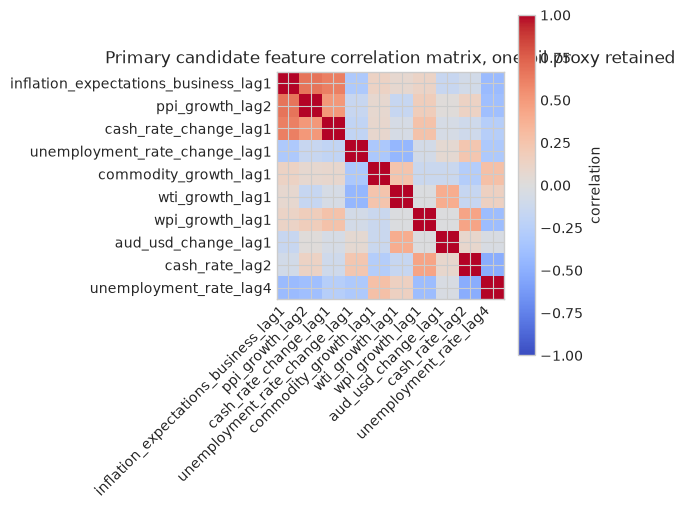

,candidate_feature,vif
0,inflation_expectations_business_lag1,9.167
6,wpi_growth_lag1,7.525
9,unemployment_rate_lag4,6.864
8,cash_rate_lag2,5.626
1,ppi_growth_lag2,5.468
5,wti_growth_lag1,2.169
2,cash_rate_change_lag1,1.911
7,aud_usd_change_lag1,1.656
3,unemployment_rate_change_lag1,1.596
4,commodity_growth_lag1,1.330


In [38]:
def lag_base_name(feature: str) -> str:
    return re.sub(r'_lag\d+$', '', feature)


def feature_lag(feature: str) -> int | None:
    match = re.search(r'_lag(\d+)$', feature)
    return int(match.group(1)) if match else None


availability_assumptions = pd.read_csv(AVAILABILITY_PATH)
availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)

# Notebook-only rate-change features inherit the release-lag assumption of their
# source rate level; no exact release dates are fabricated here.
for source_col in RATE_CHANGE_LAG_MAP:
    change_col = f'{source_col}_change'
    if change_col in EXTERNAL_BASE_COLS and change_col not in set(availability_assumptions['variable']) and source_col in set(availability_assumptions['variable']):
        source_row = availability_assumptions.loc[availability_assumptions['variable'] == source_col].iloc[0].copy()
        source_row['variable'] = change_col
        source_row['source_family'] = f"derived {source_row['source_family']} change"
        source_row['assumption_note'] = f"Inherits {source_col} release-lag assumption; transformed as percentage-point change."
        availability_assumptions = pd.concat([availability_assumptions, source_row.to_frame().T], ignore_index=True)

missing_availability_metadata = sorted(set(EXTERNAL_BASE_COLS) - set(availability_assumptions['variable']))
if missing_availability_metadata:
    raise ValueError(f'Missing availability metadata for: {missing_availability_metadata}')

availability_assumptions['assumed_min_safe_lag_quarters'] = availability_assumptions['assumed_min_safe_lag_quarters'].astype(int)
availability_lookup = availability_assumptions.set_index('variable')['assumed_min_safe_lag_quarters'].to_dict()
lagged_feature_bases = {lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES}

def min_safe_lag_for_base(base: str) -> int:
    return int(availability_lookup.get(base, 0))


def choose_safe_lagged_feature(base: str, matching_features: list[str]) -> str | None:
    min_safe_lag = min_safe_lag_for_base(base)
    safe_features = [feature for feature in matching_features if (feature_lag(feature) or -1) >= min_safe_lag]
    if not safe_features:
        return None
    preferred_lag = max(int(best_lag_lookup.get(base, feature_lag(safe_features[0]) or min_safe_lag)), min_safe_lag)
    exact = [feature for feature in safe_features if feature_lag(feature) == preferred_lag]
    if exact:
        return exact[0]
    at_or_above_preferred = [feature for feature in safe_features if (feature_lag(feature) or 99) >= preferred_lag]
    return sorted(at_or_above_preferred or safe_features, key=lambda feature: feature_lag(feature) or 99)[0]


def ccf_corr_at_lag(variable: str, lag: int | None) -> float:
    if lag is None:
        return np.nan
    match = ccf.loc[(ccf['variable'] == variable) & (ccf['lag_quarters'] == lag), 'correlation']
    return float(match.iloc[0]) if not match.empty else np.nan


def granger_p_at_lag(variable: str, lag: int | None) -> float:
    if lag is None or granger_lag_results.empty:
        return np.nan
    match = granger_lag_results.loc[(granger_lag_results['variable'] == variable) & (granger_lag_results['lag_quarters'] == lag), 'granger_p_value']
    return float(match.iloc[0]) if not match.empty else np.nan


SARIMAX_CANDIDATE_BASE_PRIORITY = [
    'inflation_expectations_business',
    'ppi_growth',
    'cash_rate_change',
    'unemployment_rate_change',
    'commodity_growth',
    'wti_growth',
    'brent_growth',
    'wpi_growth',
    'aud_usd_change',
    'household_spending_growth',
]
all_lagged_bases = sorted({lag_base_name(feature) for feature in EXTERNAL_LAGGED_FEATURES})
base_screen_order = [base for base in SARIMAX_CANDIDATE_BASE_PRIORITY if base in all_lagged_bases]
base_screen_order += [base for base in all_lagged_bases if base not in base_screen_order and not base.startswith('cpi_')]

feature_choices = []
for base in base_screen_order:
    matching_features = [feature for feature in EXTERNAL_LAGGED_FEATURES if lag_base_name(feature) == base]
    chosen = choose_safe_lagged_feature(base, matching_features)
    if chosen is not None and df[chosen].notna().mean() >= 0.50:
        feature_choices.append(chosen)

candidate_features = list(dict.fromkeys(feature_choices))

# WTI and Brent are near-substitutes. Keep both in the candidate diagnostic table,
# but compute the primary VIF matrix with at most one oil-price measure. WTI has
# longer historical coverage in this dataset, so it is preferred when both appear.
oil_pair_decision = pd.DataFrame()
vif_features = candidate_features.copy()
if 'wti_growth_lag1' in candidate_features and 'brent_growth_lag1' in candidate_features:
    wti_coverage = float(coverage.set_index('variable').loc['wti_growth', 'coverage_pct'])
    brent_coverage = float(coverage.set_index('variable').loc['brent_growth', 'coverage_pct'])
    preferred_oil_feature = 'wti_growth_lag1' if wti_coverage >= brent_coverage else 'brent_growth_lag1'
    dropped_oil_feature = 'brent_growth_lag1' if preferred_oil_feature == 'wti_growth_lag1' else 'wti_growth_lag1'
    vif_features = [feature for feature in vif_features if feature != dropped_oil_feature]
    oil_pair_decision = pd.DataFrame([{
        'preferred_oil_feature_for_primary_vif': preferred_oil_feature,
        'alternative_oil_feature': dropped_oil_feature,
        'wti_growth_coverage_pct': wti_coverage,
        'brent_growth_coverage_pct': brent_coverage,
        'reason': 'WTI and Brent growth are alternative oil-price proxies; include at most one in a SARIMAX specification.',
    }])

candidate_feature_diagnostics = pd.DataFrame([
    {
        'candidate_feature': feature,
        'variable': lag_base_name(feature),
        'candidate_lag': feature_lag(feature),
        'candidate_corr': ccf_corr_at_lag(lag_base_name(feature), feature_lag(feature)),
        'candidate_abs_corr': abs(ccf_corr_at_lag(lag_base_name(feature), feature_lag(feature))),
        'candidate_granger_p_value': granger_p_at_lag(lag_base_name(feature), feature_lag(feature)),
        'best_ccf_lag': int(best_lag_lookup.get(lag_base_name(feature), np.nan)) if lag_base_name(feature) in best_lag_lookup else np.nan,
        'best_ccf_corr': ccf_corr_at_lag(lag_base_name(feature), int(best_lag_lookup.get(lag_base_name(feature), 1))) if lag_base_name(feature) in best_lag_lookup else np.nan,
        'available_observations': int(coverage.set_index('variable').loc[lag_base_name(feature), 'available_observations']) if lag_base_name(feature) in set(coverage['variable']) else np.nan,
        'coverage_pct': float(coverage.set_index('variable').loc[lag_base_name(feature), 'coverage_pct']) if lag_base_name(feature) in set(coverage['variable']) else np.nan,
    }
    for feature in candidate_features
])
display(candidate_feature_diagnostics.round({'candidate_corr': 3, 'candidate_abs_corr': 3, 'candidate_granger_p_value': 4, 'best_ccf_corr': 3, 'coverage_pct': 3}))
if not oil_pair_decision.empty:
    display(oil_pair_decision.round(3))

candidate_matrix = df[vif_features].apply(pd.to_numeric, errors='coerce').dropna()
display(pd.DataFrame({'primary_vif_feature': vif_features}))

candidate_sample_summary = {'complete_rows_for_corr_vif': int(len(candidate_matrix))}
if not candidate_matrix.empty:
    candidate_quarters = df.loc[candidate_matrix.index, 'quarter_period']
    candidate_sample_summary.update({'start_quarter': str(candidate_quarters.iloc[0]), 'end_quarter': str(candidate_quarters.iloc[-1])})
display(pd.DataFrame([candidate_sample_summary]))

if len(vif_features) >= 2 and len(candidate_matrix) >= 24:
    corr_matrix = candidate_matrix.corr()
    display(corr_matrix.round(3))
    fig, ax = plt.subplots(figsize=(max(6, 0.6 * len(vif_features)), max(5, 0.55 * len(vif_features))))
    image = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title('Primary candidate feature correlation matrix, one oil proxy retained')
    fig.colorbar(image, ax=ax, label='correlation')
    fig.tight_layout()
    plt.show()

    vif_rows = []
    vif_input = candidate_matrix.astype(float)
    for index, feature in enumerate(vif_input.columns):
        vif_rows.append({'candidate_feature': feature, 'vif': variance_inflation_factor(vif_input.values, index)})
    vif = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
else:
    vif = pd.DataFrame({'candidate_feature': vif_features, 'vif': np.nan, 'note': 'not enough candidate features or complete rows for VIF'})

display(vif.round(3))

## 9. Leakage And Forecast-Origin Availability Assumptions

The curated schema does not contain publication dates. The metadata file below is an explicit assumption set for a one-quarter-ahead modelling workflow. It distinguishes the observation quarter, the release/publication lag, and the forecast origin, but it does not contain true historical release vintages. The project currently uses revised historical ABS/RBA/market data, so the safe-lag check is a transparent leakage-control assumption rather than a real-time data audit.

In [39]:
feature_availability = []
for feature in EXTERNAL_LAGGED_FEATURES:
    base = lag_base_name(feature)
    lag = feature_lag(feature)
    assumption = availability_assumptions.loc[availability_assumptions['variable'] == base]
    min_safe_lag = int(assumption['assumed_min_safe_lag_quarters'].iloc[0]) if not assumption.empty else np.nan
    feature_availability.append({
        'candidate_feature': feature,
        'variable': base,
        'feature_lag_quarters': lag,
        'assumed_min_safe_lag_quarters': min_safe_lag,
        'forecast_origin_safe_under_assumption': bool(pd.notna(min_safe_lag) and lag >= min_safe_lag),
    })

feature_availability = pd.DataFrame(feature_availability)
display(availability_assumptions)
display(feature_availability)

,variable,source_family,assumed_min_safe_lag_quarters,assumption_note
0,unemployment_rate,ABS labour force,1,Monthly labour data can be revised and should ...
1,cash_rate,RBA policy rate,0,Policy rate is public when set; lagged feature...
2,wage_price_index,ABS WPI,1,Quarterly WPI is typically released after CPI ...
3,wpi_growth,derived ABS WPI growth,1,Inherits WPI release lag.
4,producer_price_index,ABS PPI,1,Conservative quarterly release-lag assumption.
5,ppi_growth,derived ABS PPI growth,1,Inherits PPI release lag.
6,commodity_price_index,RBA commodity index,1,Monthly or quarterly aggregation should avoid ...
7,commodity_growth,derived RBA commodity growth,1,Inherits commodity index aggregation lag.
8,wti_price,market price,0,Market data is observable daily; lagged featur...
9,wti_growth,derived WTI growth,0,Inherits market-data availability.


,candidate_feature,variable,feature_lag_quarters,assumed_min_safe_lag_quarters,forecast_origin_safe_under_assumption
0,cash_rate_lag1,cash_rate,1,0,True
1,cash_rate_lag2,cash_rate,2,0,True
2,cash_rate_lag4,cash_rate,4,0,True
3,unemployment_rate_lag1,unemployment_rate,1,1,True
4,unemployment_rate_lag2,unemployment_rate,2,1,True
5,unemployment_rate_lag4,unemployment_rate,4,1,True
6,wpi_growth_lag1,wpi_growth,1,1,True
7,wpi_growth_lag2,wpi_growth,2,1,True
8,ppi_growth_lag1,ppi_growth,1,1,True
9,ppi_growth_lag2,ppi_growth,2,1,True


## 10. Candidate Exogenous Feature Screening For SARIMAX

This table is a SARIMAX candidate pool, not final feature selection. EDA diagnostics such as CCF, Granger tests, VIF, missingness, and stability checks identify plausible regressors. The final SARIMAX specification must be selected later with rolling-origin or walk-forward forecasting performance. In short: EDA screens candidate regressors; out-of-sample rolling-origin forecasting selects the final SARIMAX specification.

In [40]:
candidate_diag_lookup = candidate_feature_diagnostics.set_index('candidate_feature') if not candidate_feature_diagnostics.empty else pd.DataFrame()
chosen_feature_by_base = {lag_base_name(feature): feature for feature in candidate_features}
vif_lookup = vif.set_index('candidate_feature')['vif'].to_dict() if not vif.empty else {}
coverage_lookup = coverage.set_index('variable')
stationarity_lookup = stationarity.set_index('variable')
ccf_lookup = best_predictive_ccf.set_index('variable')
granger_lookup_frame = granger.set_index('variable')
oil_alternative_features = set(oil_pair_decision['alternative_oil_feature']) if not oil_pair_decision.empty else set()


def classify_candidate(row: pd.Series) -> tuple[str, str]:
    blockers = []
    warnings = []
    signals = []

    if not row.get('has_lag_feature', False):
        blockers.append('no lagged feature engineered in this notebook/src/features.py')
    elif pd.isna(row.get('feature_lag_quarters')):
        blockers.append('no candidate lag selected after availability/sample screen')
    elif row.get('forecast_origin_safe_under_assumption') is False:
        blockers.append('unsafe under assumed publication-lag metadata')

    if pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD:
        warnings.append('high VIF in primary candidate matrix')
    if row.get('late_start_reduces_estimation_sample', False):
        warnings.append('starts later than full sample; reduces estimation window')
    if row.get('substantial_missingness_warning', False):
        warnings.append('substantial missingness warning')
    if row.get('candidate_feature') in oil_alternative_features:
        warnings.append('alternative oil proxy; use at most one of WTI/Brent in a SARIMAX specification')

    if pd.notna(row.get('candidate_abs_corr')) and row.get('candidate_abs_corr') >= SIGNAL_CORR_THRESHOLD:
        signals.append('candidate-lag CCF signal')
    if pd.notna(row.get('candidate_granger_p_value')) and row.get('candidate_granger_p_value') <= SIGNAL_P_THRESHOLD:
        signals.append('candidate-lag Granger screening signal')

    if blockers:
        return 'exclude', '; '.join(blockers + warnings) if warnings else '; '.join(blockers)
    if not signals:
        return 'optional', '; '.join(warnings + ['weak candidate-lag CCF/Granger screening signal']) if warnings else 'weak candidate-lag CCF/Granger screening signal'
    strong_signal = (
        pd.notna(row.get('candidate_abs_corr')) and row.get('candidate_abs_corr') >= 0.40
    ) or (
        pd.notna(row.get('candidate_granger_p_value')) and row.get('candidate_granger_p_value') <= 0.05
    )
    if strong_signal and not row.get('substantial_missingness_warning', False) and not (pd.notna(row.get('vif')) and row.get('vif') > VIF_THRESHOLD):
        return 'strong candidate', '; '.join(warnings + signals) if warnings else '; '.join(signals)
    if warnings:
        return 'optional/shorter-sample candidate', '; '.join(warnings + signals)
    return 'candidate', '; '.join(signals)


shortlist_rows = []
for variable in EXTERNAL_BASE_COLS:
    chosen_feature = chosen_feature_by_base.get(variable)
    availability_row = feature_availability.loc[feature_availability['candidate_feature'] == chosen_feature].iloc[0].to_dict() if chosen_feature in set(feature_availability['candidate_feature']) else {}
    candidate_row = candidate_diag_lookup.loc[chosen_feature].to_dict() if chosen_feature in candidate_diag_lookup.index else {}
    row = {
        'variable': variable,
        'candidate_feature': chosen_feature,
        'has_lag_feature': variable in lagged_feature_bases,
        'integration_order': stationarity_lookup.loc[variable, 'integration_order'] if variable in stationarity_lookup.index else None,
        'best_ccf_lag': int(ccf_lookup.loc[variable, 'lag_quarters']) if variable in ccf_lookup.index else np.nan,
        'best_ccf_corr': ccf_lookup.loc[variable, 'correlation'] if variable in ccf_lookup.index else np.nan,
        'candidate_lag': candidate_row.get('candidate_lag', np.nan),
        'candidate_corr': candidate_row.get('candidate_corr', np.nan),
        'candidate_abs_corr': candidate_row.get('candidate_abs_corr', np.nan),
        'candidate_granger_p_value': candidate_row.get('candidate_granger_p_value', np.nan),
        'min_granger_p_value': granger_lookup_frame.loc[variable, 'min_granger_p_value'] if variable in granger_lookup_frame.index else np.nan,
        'vif': vif_lookup.get(chosen_feature, np.nan),
        'assumed_min_safe_lag_quarters': availability_assumptions.set_index('variable').loc[variable, 'assumed_min_safe_lag_quarters'] if variable in set(availability_assumptions['variable']) else np.nan,
        'feature_lag_quarters': availability_row.get('feature_lag_quarters', np.nan),
        'forecast_origin_safe_under_assumption': availability_row.get('forecast_origin_safe_under_assumption', False),
        'available_observations': coverage_lookup.loc[variable, 'available_observations'] if variable in coverage_lookup.index else np.nan,
        'coverage_pct': coverage_lookup.loc[variable, 'coverage_pct'] if variable in coverage_lookup.index else np.nan,
        'missing_pct': coverage_lookup.loc[variable, 'missing_pct'] if variable in coverage_lookup.index else np.nan,
        'first_non_null': coverage_lookup.loc[variable, 'first_non_null'] if variable in coverage_lookup.index else None,
        'last_non_null': coverage_lookup.loc[variable, 'last_non_null'] if variable in coverage_lookup.index else None,
        'coverage_class': coverage_lookup.loc[variable, 'coverage_class'] if variable in coverage_lookup.index else None,
        'late_start_reduces_estimation_sample': bool(coverage_lookup.loc[variable, 'late_start_reduces_estimation_sample']) if variable in coverage_lookup.index else True,
        'substantial_missingness_warning': bool(coverage_lookup.loc[variable, 'substantial_missingness_warning']) if variable in coverage_lookup.index else True,
    }
    row['screening_status'], row['reason'] = classify_candidate(pd.Series(row))
    shortlist_rows.append(row)

shortlist = pd.DataFrame(shortlist_rows).sort_values(['screening_status', 'candidate_granger_p_value', 'candidate_abs_corr'], ascending=[True, True, False])
display(shortlist.round({'best_ccf_corr': 3, 'candidate_corr': 3, 'candidate_abs_corr': 3, 'candidate_granger_p_value': 4, 'min_granger_p_value': 4, 'vif': 2, 'missing_pct': 3, 'coverage_pct': 3}))

strong_or_candidate_features = shortlist.loc[shortlist['screening_status'].isin(['strong candidate', 'candidate', 'optional/shorter-sample candidate']), 'candidate_feature'].dropna().tolist()
if strong_or_candidate_features:
    message = 'SARIMAX candidate pool from EDA screening: ' + ', '.join(strong_or_candidate_features)
else:
    message = 'No external variables passed the candidate screening checks. Revisit feature engineering before SARIMAX modelling.'

display(Markdown(message + '\n\nThese are not final feature-selection results. The modelling stage should compare a small set of nested SARIMAX specifications, for example: expectations + PPI; then add cash-rate change; then unemployment change + commodity growth; then one oil-price measure. Final selection should use walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample. This shortlist targets SARIMAX exogenous regressors only; LSTM input selection may use a broader or differently lagged feature set and is out of scope for this notebook.'))

,variable,candidate_feature,has_lag_feature,integration_order,best_ccf_lag,best_ccf_corr,candidate_lag,candidate_corr,candidate_abs_corr,candidate_granger_p_value,min_granger_p_value,vif,assumed_min_safe_lag_quarters,feature_lag_quarters,forecast_origin_safe_under_assumption,available_observations,coverage_pct,missing_pct,first_non_null,last_non_null,coverage_class,late_start_reduces_estimation_sample,substantial_missingness_warning,screening_status,reason
0,unemployment_rate,unemployment_rate_lag4,True,I(1),3,-0.303,4.0,-0.226,0.226,0.2426,0.0091,6.86,1,4.0,True,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,candidate,candidate-lag CCF signal
2,wage_price_index,NaN,False,I(2),2,0.064,NaN,NaN,NaN,NaN,0.8303,NaN,1,NaN,False,114,0.919,0.081,1997Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
4,producer_price_index,NaN,False,I(1),2,0.552,NaN,NaN,NaN,NaN,0.0100,NaN,1,NaN,False,110,0.887,0.113,1998Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
6,commodity_price_index,NaN,False,I(1),2,0.263,NaN,NaN,NaN,NaN,0.0234,NaN,1,NaN,False,124,1.000,0.000,1995Q1,2025Q4,core_long_sample_candidate,False,False,exclude,no lagged feature engineered in this notebook/...
8,wti_price,NaN,False,I(1),3,0.343,NaN,NaN,NaN,NaN,0.0001,NaN,0,NaN,False,102,0.823,0.177,2000Q3,2025Q4,shorter_sample_candidate,True,False,exclude,no lagged feature engineered in this notebook/...
10,brent_price,NaN,False,I(0),1,0.471,NaN,NaN,NaN,NaN,0.0200,NaN,0,NaN,False,74,0.597,0.403,2007Q3,2025Q4,limited_sample_candidate,True,True,exclude,no lagged feature engineered in this notebook/...
12,aud_usd,NaN,False,I(1),4,0.033,NaN,NaN,NaN,NaN,0.1762,NaN,0,NaN,False,64,0.516,0.484,2010Q1,2025Q4,limited_sample_candidate,True,True,exclude,no lagged feature engineered in this notebook/...
14,household_spending,NaN,False,I(1),3,0.476,NaN,NaN,NaN,NaN,0.0057,NaN,1,NaN,False,54,0.435,0.565,2012Q3,2025Q4,exclude_low_coverage,True,True,exclude,no lagged feature engineered in this notebook/...
15,household_spending_growth,NaN,False,I(0),3,0.489,NaN,NaN,NaN,NaN,0.0023,NaN,1,NaN,False,53,0.427,0.573,2012Q4,2025Q4,exclude_low_coverage,True,True,exclude,no lagged feature engineered in this notebook/...
13,aud_usd_change,aud_usd_change_lag1,True,I(0),4,0.031,1.0,-0.008,0.008,0.1749,0.1749,1.66,0,1.0,True,63,0.508,0.492,2010Q2,2025Q4,limited_sample_candidate,True,True,optional,starts later than full sample; reduces estimat...


SARIMAX candidate pool from EDA screening: unemployment_rate_lag4, brent_growth_lag1, cash_rate_change_lag1, inflation_expectations_business_lag1, cash_rate_lag2, wti_growth_lag1, unemployment_rate_change_lag1, ppi_growth_lag2, commodity_growth_lag1

These are not final feature-selection results. The modelling stage should compare a small set of nested SARIMAX specifications, for example: expectations + PPI; then add cash-rate change; then unemployment change + commodity growth; then one oil-price measure. Final selection should use walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample. This shortlist targets SARIMAX exogenous regressors only; LSTM input selection may use a broader or differently lagged feature set and is out of scope for this notebook.

## 11. Rolling Correlations / Relationship Stability

This section checks whether CPI-predictor relationships are stable through time. It reuses the stationary transformations from the CCF section and applies forecast-safe lags where engineered lag features are available. These diagnostics are supplementary and are not fed back into the Section 10 include/exclude logic.

,variable,lag_used,rolling_windows,rolling_corr_min,rolling_corr_max,mean_abs_rolling_corr,rolling_corr_std,raw_sign_changes,strong_sign_changes,weak_window_share,covid_or_post_covid_only_signal,sign_change,rolling_relationship_stable,stability_warning,unstable_flag
16,wpi_growth,1,92,-0.117,0.271,0.066,0.072,22,0,0.967,False,False,False,weak in more than half of rolling windows,True
15,wage_price_index,1,92,-0.112,0.283,0.067,0.071,22,0,0.967,False,False,False,weak in more than half of rolling windows,True
1,aud_usd_change,1,43,-0.469,0.459,0.170,0.223,5,1,0.628,False,True,False,strong sign change; weak in more than half of ...,True
18,wti_price,0,82,-0.450,0.474,0.186,0.220,10,2,0.573,False,True,False,strong sign change; weak in more than half of ...,True
13,unemployment_rate,4,100,-0.424,0.517,0.186,0.227,12,6,0.540,True,True,False,strong sign change; weak in more than half of ...,True
17,wti_growth,1,81,-0.337,0.551,0.233,0.186,4,4,0.370,True,True,False,strong sign change; signal concentrated in COV...,True
9,household_spending_growth,1,33,0.020,0.517,0.301,0.136,0,0,0.364,True,False,False,signal concentrated in COVID/post-COVID period,True
8,household_spending,1,33,0.036,0.520,0.306,0.134,0,0,0.333,True,False,False,signal concentrated in COVID/post-COVID period,True
14,unemployment_rate_change,1,101,-0.610,0.571,0.297,0.331,6,3,0.297,True,True,False,strong sign change; large rolling-correlation ...,True
0,aud_usd,0,44,-0.581,0.490,0.331,0.344,1,1,0.295,False,True,False,strong sign change; large rolling-correlation ...,True


period,covid,gfc,post_covid,post_gfc_pre_covid,pre_gfc
variable,,,,,
aud_usd,-0.62 (n=8),not tested,-0.28 (n=16),0.26 (n=39),not tested
aud_usd_change,0.02 (n=8),not tested,-0.28 (n=16),0.28 (n=38),not tested
brent_growth,0.59 (n=8),not tested,0.11 (n=16),0.24 (n=42),not tested
brent_price,0.89 (n=8),not tested,0.65 (n=16),0.64 (n=42),not tested
cash_rate,0.40 (n=8),not tested,0.50 (n=16),0.32 (n=42),0.57 (n=50)
cash_rate_change,0.49 (n=8),not tested,0.77 (n=16),0.44 (n=42),0.44 (n=50)
commodity_growth,0.49 (n=8),not tested,0.26 (n=16),0.34 (n=42),0.32 (n=50)
commodity_price_index,0.48 (n=8),not tested,0.25 (n=16),0.34 (n=42),0.32 (n=50)
household_spending,0.03 (n=8),not tested,0.52 (n=16),0.17 (n=28),not tested


Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.

,variable,candidate_feature,screening_status,rolling_relationship_stable,rolling_corr_min,rolling_corr_max,sign_change,stability_warning
0,unemployment_rate,unemployment_rate_lag4,candidate,False,-0.424,0.517,True,strong sign change; weak in more than half of ...
1,wage_price_index,NaN,exclude,False,-0.112,0.283,False,weak in more than half of rolling windows
2,producer_price_index,NaN,exclude,False,-0.319,0.808,True,strong sign change
3,commodity_price_index,NaN,exclude,True,-0.021,0.691,False,
4,wti_price,NaN,exclude,False,-0.450,0.474,True,strong sign change; weak in more than half of ...
5,brent_price,NaN,exclude,True,-0.089,0.894,False,
6,aud_usd,NaN,exclude,False,-0.581,0.490,True,strong sign change; large rolling-correlation ...
7,household_spending,NaN,exclude,False,0.036,0.520,False,signal concentrated in COVID/post-COVID period
8,household_spending_growth,NaN,exclude,False,0.020,0.517,False,signal concentrated in COVID/post-COVID period
9,aud_usd_change,aud_usd_change_lag1,optional,False,-0.469,0.459,True,strong sign change; weak in more than half of ...


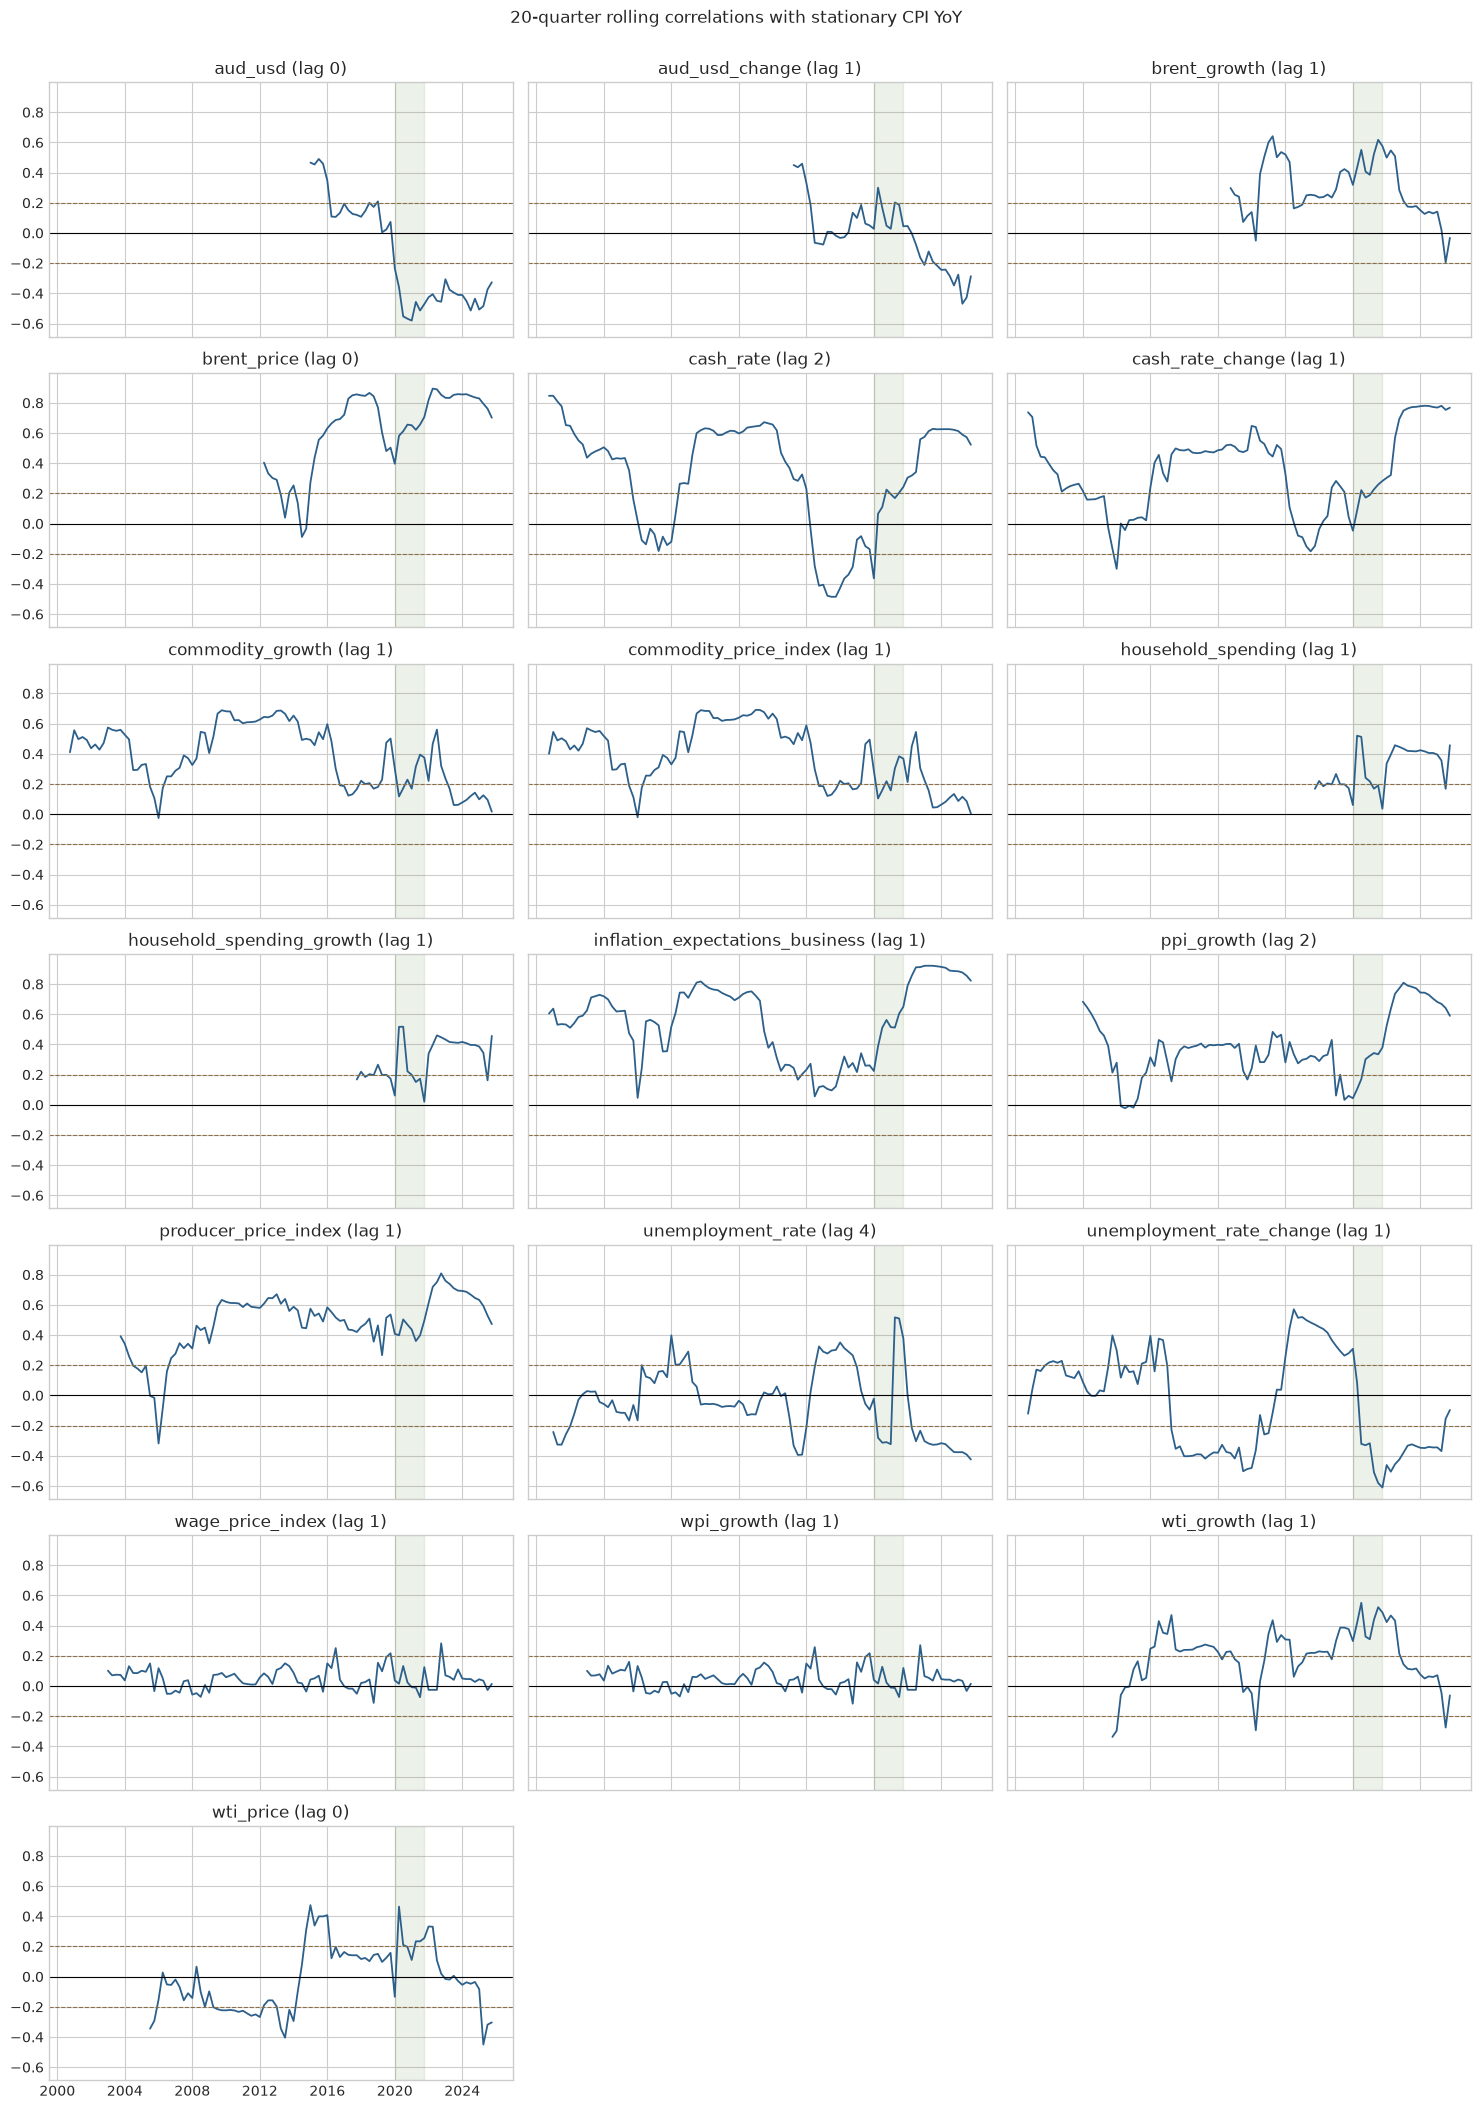

In [41]:
ROLLING_WINDOW = 20

def rolling_feature_lag(variable: str) -> int:
    chosen_feature = chosen_feature_by_base.get(variable)
    if chosen_feature is not None and pd.notna(feature_lag(chosen_feature)):
        return int(feature_lag(chosen_feature))
    return min_safe_lag_for_base(variable) if variable in availability_lookup else 0


def count_strong_sign_changes(corr: pd.Series, threshold: float) -> int:
    strong = corr.dropna()[corr.dropna().abs() >= threshold]
    signs = np.sign(strong)
    if len(signs) <= 1:
        return 0
    return int((signs != signs.shift()).sum() - 1)

rolling_corr_frames = []
period_rows = []
for variable in EXTERNAL_BASE_COLS:
    lag = rolling_feature_lag(variable)
    x_stationary = stationary_series(variable).rename(variable).shift(lag)
    aligned = pd.concat([target_stationary.rename(TARGET), x_stationary], axis=1).dropna()
    if len(aligned) < ROLLING_WINDOW:
        continue
    rolling_corr = aligned[TARGET].rolling(ROLLING_WINDOW).corr(aligned[variable]).dropna()
    rolling_corr_frames.append(pd.DataFrame({'quarter_period': rolling_corr.index, 'variable': variable, 'rolling_corr': rolling_corr.values, 'lag_used': lag}))

    periods = {
        'pre_gfc': aligned.index < pd.Period('2008Q3', freq='Q'),
        'gfc': (aligned.index >= pd.Period('2008Q3', freq='Q')) & (aligned.index <= pd.Period('2009Q2', freq='Q')),
        'post_gfc_pre_covid': (aligned.index >= pd.Period('2009Q3', freq='Q')) & (aligned.index < pd.Period('2020Q1', freq='Q')),
        'covid': (aligned.index >= pd.Period('2020Q1', freq='Q')) & (aligned.index <= pd.Period('2021Q4', freq='Q')),
        'post_covid': aligned.index >= pd.Period('2022Q1', freq='Q'),
    }
    for period_name, mask in periods.items():
        subset = aligned.loc[mask]
        period_rows.append({
            'variable': variable,
            'period': period_name,
            'lag_used': lag,
            'n_obs': int(len(subset)),
            'period_corr': subset[TARGET].corr(subset[variable]) if len(subset) >= 8 else np.nan,
        })

rolling_corrs = pd.concat(rolling_corr_frames, ignore_index=True) if rolling_corr_frames else pd.DataFrame(columns=['quarter_period', 'variable', 'rolling_corr', 'lag_used'])
period_correlation = pd.DataFrame(period_rows)

stability_rows = []
for variable, group in rolling_corrs.groupby('variable'):
    corr = group['rolling_corr'].dropna()
    signs = np.sign(corr.replace(0, np.nan)).dropna()
    raw_sign_changes = int((signs != signs.shift()).sum() - 1) if len(signs) > 1 else 0
    strong_sign_changes = count_strong_sign_changes(corr, SIGNAL_CORR_THRESHOLD)
    weak_share = float((corr.abs() < SIGNAL_CORR_THRESHOLD).mean()) if len(corr) else np.nan
    period_values = period_correlation.loc[period_correlation['variable'] == variable].set_index('period')['period_corr']
    pre_covid_abs_values = period_values.reindex(['pre_gfc', 'gfc', 'post_gfc_pre_covid']).abs().dropna()
    pre_abs = pre_covid_abs_values.max() if not pre_covid_abs_values.empty else np.nan
    covid_abs = abs(period_values.get('covid', np.nan))
    post_abs = abs(period_values.get('post_covid', np.nan))
    crisis_or_post_signal = (pd.notna(covid_abs) and covid_abs >= SIGNAL_CORR_THRESHOLD) or (pd.notna(post_abs) and post_abs >= SIGNAL_CORR_THRESHOLD)
    covid_or_post_only = bool(crisis_or_post_signal and (pd.isna(pre_abs) or pre_abs < SIGNAL_CORR_THRESHOLD))
    stability_rows.append({
        'variable': variable,
        'lag_used': int(group['lag_used'].iloc[0]),
        'rolling_windows': int(len(corr)),
        'rolling_corr_min': corr.min(),
        'rolling_corr_max': corr.max(),
        'mean_abs_rolling_corr': corr.abs().mean(),
        'rolling_corr_std': corr.std(),
        'raw_sign_changes': max(raw_sign_changes, 0),
        'strong_sign_changes': max(strong_sign_changes, 0),
        'weak_window_share': weak_share,
        'covid_or_post_covid_only_signal': covid_or_post_only,
        'sign_change': bool(max(strong_sign_changes, 0) > 0),
        'rolling_relationship_stable': not bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
        'stability_warning': '; '.join([reason for condition, reason in [
            (max(strong_sign_changes, 0) > 0, 'strong sign change'),
            (weak_share > 0.50, 'weak in more than half of rolling windows'),
            (corr.std() > 0.30, 'large rolling-correlation variation'),
            (covid_or_post_only, 'signal concentrated in COVID/post-COVID period'),
        ] if condition]),
        'unstable_flag': bool(max(strong_sign_changes, 0) > 0 or weak_share > 0.50 or corr.std() > 0.30 or covid_or_post_only),
    })

stability_summary = pd.DataFrame(stability_rows).sort_values(['unstable_flag', 'weak_window_share', 'rolling_corr_std'], ascending=[False, False, False])
display(stability_summary.round(3))

period_display = period_correlation.copy()
period_display['corr_with_n'] = period_display.apply(
    lambda row: 'not tested' if pd.isna(row['period_corr']) else f"{row['period_corr']:.2f} (n={int(row['n_obs'])})",
    axis=1,
)
display(period_display.pivot(index='variable', columns='period', values='corr_with_n'))
display(Markdown('Short-regime correlations, especially GFC and COVID windows, can be based on very few quarterly observations, so period-specific correlations are indicative only. The instability flag uses strong sign changes after a correlation dead-band, weak rolling-correlation share, rolling variation, and crisis-period concentration.'))

shortlist_with_stability = shortlist.merge(
    stability_summary[['variable', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']],
    on='variable',
    how='left',
)
display(shortlist_with_stability[['variable', 'candidate_feature', 'screening_status', 'rolling_relationship_stable', 'rolling_corr_min', 'rolling_corr_max', 'sign_change', 'stability_warning']].round({'rolling_corr_min': 3, 'rolling_corr_max': 3}))

if not rolling_corrs.empty:
    n_cols = 3
    n_rows = int(np.ceil(rolling_corrs['variable'].nunique() / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, max(4, 3.0 * n_rows)), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    for ax, (variable, group) in zip(axes, rolling_corrs.groupby('variable')):
        plot_dates = pd.PeriodIndex(group['quarter_period'], freq='Q').to_timestamp(how='start')
        ax.plot(plot_dates, group['rolling_corr'], color='#2c5f8a', linewidth=1.3)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axhline(-SIGNAL_CORR_THRESHOLD, color='#8b6f47', linestyle='--', linewidth=0.8)
        ax.axvspan(pd.Period('2020Q1', freq='Q').to_timestamp(), pd.Period('2021Q4', freq='Q').to_timestamp(), color='#6a8f4e', alpha=0.12)
        ax.set_title(f'{variable} (lag {int(group["lag_used"].iloc[0])})')
    for ax in axes[rolling_corrs['variable'].nunique():]:
        ax.axis('off')
    fig.suptitle(f'{ROLLING_WINDOW}-quarter rolling correlations with stationary CPI YoY', y=1.002)
    fig.tight_layout()
    plt.show()

## 12. Raw Source Frequency Validation Spot Check

The notebook primarily validates the curated quarterly modelling table. This light spot check reconciles two representative raw inputs against the curated quarterly values using the ETL rule in `src.transform.to_quarterly()` and the source-specific aggregation configured in `src.build_curated_dataset.SeriesSpec`. It is not a full raw-source audit.

In [42]:
from src.transform import to_quarterly
from src.validation import find_date_column

spot_specs = [
    {
        'variable': 'cash_rate',
        'source_family': 'RBA cash rate',
        'source_frequency': 'monthly',
        'path': ROOT / 'dataset' / 'rba' / 'cash_rate_1995_2025.csv',
        'value_col': 'cash_rate',
        'agg': 'mean',
    },
    {
        'variable': 'wti_price',
        'source_family': 'market WTI crude oil',
        'source_frequency': 'daily trading days',
        'path': ROOT / 'dataset' / 'market' / 'wti_crude_oil_1995_2025.csv',
        'value_col': 'Close',
        'agg': 'mean',
    },
]

spot_rows = []
frequency_rows = []
curated_lookup = df_model.set_index('quarter')
for spec in spot_specs:
    raw = pd.read_csv(spec['path'])
    date_col = find_date_column(raw)
    parsed_dates = pd.to_datetime(raw[date_col], errors='coerce')
    parsed_non_null = parsed_dates.dropna().sort_values()
    inferred_frequency = pd.infer_freq(parsed_non_null.head(12)) if len(parsed_non_null) >= 12 else None
    median_spacing_days = parsed_non_null.diff().dt.days.dropna().median() if len(parsed_non_null) > 1 else np.nan
    duplicate_dates = int(parsed_dates.duplicated().sum())

    frequency_rows.append({
        'variable': spec['variable'],
        'source_family': spec['source_family'],
        'source_frequency': spec['source_frequency'],
        'raw_rows': int(len(raw)),
        'date_col': date_col,
        'start_date': parsed_non_null.min().date() if len(parsed_non_null) else None,
        'end_date': parsed_non_null.max().date() if len(parsed_non_null) else None,
        'duplicate_dates': duplicate_dates,
        'inferred_frequency_head': inferred_frequency,
        'median_spacing_days': median_spacing_days,
    })

    quarterly = to_quarterly(raw, value_col=spec['value_col'], output_col=spec['variable'], agg=spec['agg'], date_col=date_col)
    common_quarters = [quarter for quarter in quarterly['quarter'] if quarter in curated_lookup.index and pd.notna(curated_lookup.loc[quarter, spec['variable']])]
    sample_quarters = []
    if common_quarters:
        sample_quarters.append(common_quarters[0])
    if len(common_quarters) > 1:
        sample_quarters.append(common_quarters[len(common_quarters) // 2])
    for quarter in dict.fromkeys(sample_quarters):
        raw_value = float(quarterly.loc[quarterly['quarter'] == quarter, spec['variable']].iloc[0])
        curated_value = float(curated_lookup.loc[quarter, spec['variable']])
        spot_rows.append({
            'variable': spec['variable'],
            'source_frequency': spec['source_frequency'],
            'aggregation_rule': spec['agg'],
            'spot_quarter': quarter,
            'raw_derived_value': raw_value,
            'curated_value': curated_value,
            'absolute_difference': abs(raw_value - curated_value),
            'match': bool(np.isclose(raw_value, curated_value, rtol=1e-8, atol=1e-8)),
        })

raw_frequency_spot_check = pd.DataFrame(frequency_rows)
raw_curated_reconciliation = pd.DataFrame(spot_rows)
display(raw_frequency_spot_check)
display(raw_curated_reconciliation.round({'raw_derived_value': 6, 'curated_value': 6, 'absolute_difference': 10}))

display(Markdown('This spot check verifies representative monthly and daily inputs only. Full source-level validation remains an ETL/data-quality task; this EDA validates the curated quarterly table used for modelling.'))

,variable,source_family,source_frequency,raw_rows,date_col,start_date,end_date,duplicate_dates,inferred_frequency_head,median_spacing_days
0,cash_rate,RBA cash rate,monthly,372,date,1995-01-01,2025-12-01,0,MS,31.0
1,wti_price,market WTI crude oil,daily trading days,6367,Date,2000-08-23,2025-12-31,0,NaN,1.0


,variable,source_frequency,aggregation_rule,spot_quarter,raw_derived_value,curated_value,absolute_difference,match
0,cash_rate,monthly,mean,1995Q1,7.500000,7.500000,0.0,True
1,cash_rate,monthly,mean,2010Q3,4.500000,4.500000,0.0,True
2,wti_price,daily trading days,mean,2000Q3,33.527407,33.527407,0.0,True
3,wti_price,daily trading days,mean,2013Q2,94.173281,94.173281,0.0,True


This spot check verifies representative monthly and daily inputs only. Full source-level validation remains an ETL/data-quality task; this EDA validates the curated quarterly table used for modelling.

## 14. RBA Forecast Error Benchmark Preparation

This section uses the newly retrieved RBA historical CPI forecast file as a benchmark-preparation diagnostic. It summarises forecast errors by published horizon only; formal model comparison still belongs in the rolling-origin modelling stage, where SARIMA/SARIMAX/LSTM forecasts can be aligned to the same horizons.


,horizon_quarters,n_forecasts,start_forecast_date,end_forecast_date,mean_error,mae,rmse
0,0,121,1995-03-01,2025-02-01,-0.018,0.207,0.287
1,1,121,1995-03-01,2025-02-01,-0.022,0.436,0.601
2,2,121,1995-03-01,2025-02-01,-0.025,0.633,0.894
3,3,121,1995-03-01,2025-02-01,-0.059,0.845,1.197
4,4,120,1995-03-01,2024-11-01,-0.065,1.012,1.419
5,5,119,1995-03-01,2024-08-01,-0.050,1.110,1.555
6,6,113,1995-06-01,2024-05-01,0.013,1.139,1.619
7,7,94,1995-06-01,2024-02-01,0.041,1.203,1.727
8,8,75,1995-06-01,2023-11-01,0.163,1.253,1.823
9,9,43,1998-03-01,2023-08-01,0.216,1.184,1.686


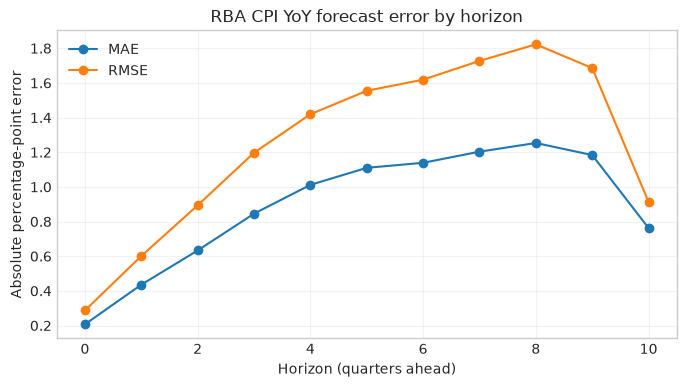

RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.

In [43]:
RBA_FORECAST_PATH = ROOT / 'dataset' / 'rba' / 'rba_historical_cpi_forecasts_by_horizon_1995_2025.csv'

if RBA_FORECAST_PATH.exists():
    rba_forecasts = pd.read_csv(RBA_FORECAST_PATH)
    rba_forecasts['forecast_date'] = pd.to_datetime(rba_forecasts['forecast_date'], errors='coerce')
    rba_eval = rba_forecasts.loc[
        rba_forecasts['horizon_quarters'].ge(0)
        & rba_forecasts['rba_forecast_cpi_yoy'].notna()
        & rba_forecasts['rba_actual_cpi_yoy'].notna()
    ].copy()
    if 'rba_forecast_error_cpi_yoy' not in rba_eval or rba_eval['rba_forecast_error_cpi_yoy'].isna().all():
        rba_eval['rba_forecast_error_cpi_yoy'] = rba_eval['rba_actual_cpi_yoy'] - rba_eval['rba_forecast_cpi_yoy']
    rba_eval = rba_eval.loc[rba_eval['rba_forecast_error_cpi_yoy'].notna()].copy()

    rba_horizon_error = (
        rba_eval.groupby('horizon_quarters')
        .agg(
            n_forecasts=('rba_forecast_error_cpi_yoy', 'size'),
            start_forecast_date=('forecast_date', 'min'),
            end_forecast_date=('forecast_date', 'max'),
            mean_error=('rba_forecast_error_cpi_yoy', 'mean'),
            mae=('rba_forecast_error_cpi_yoy', lambda s: s.abs().mean()),
            rmse=('rba_forecast_error_cpi_yoy', lambda s: np.sqrt(np.mean(np.square(s)))),
        )
        .reset_index()
    )
    rba_horizon_error['start_forecast_date'] = rba_horizon_error['start_forecast_date'].dt.strftime('%Y-%m-%d')
    rba_horizon_error['end_forecast_date'] = rba_horizon_error['end_forecast_date'].dt.strftime('%Y-%m-%d')
    display(rba_horizon_error.round({'mean_error': 3, 'mae': 3, 'rmse': 3}))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(rba_horizon_error['horizon_quarters'], rba_horizon_error['mae'], marker='o', label='MAE')
    ax.plot(rba_horizon_error['horizon_quarters'], rba_horizon_error['rmse'], marker='o', label='RMSE')
    ax.set_title('RBA CPI YoY forecast error by horizon')
    ax.set_xlabel('Horizon (quarters ahead)')
    ax.set_ylabel('Absolute percentage-point error')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

    display(Markdown('RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.'))
else:
    rba_horizon_error = pd.DataFrame()
    display(Markdown('RBA historical CPI forecast data is not present, so RBA forecast-error benchmarking remains blocked until the source file is retrieved.'))


## 13. Documented Limitations And Follow-Ups

- **Historical RBA forecast error review:** Section 14 now summarises RBA historical CPI forecast errors by horizon from `dataset/rba/rba_historical_cpi_forecasts_by_horizon_1995_2025.csv`. It is benchmark preparation only; final model comparison still needs rolling-origin SARIMA/SARIMAX/LSTM forecasts aligned to the same forecast dates and horizons.
- **Feature-pipeline follow-up:** `src.features` now owns the rate-change and lag definitions surfaced by this EDA. Regenerate `data/curated/quarterly_macro_features.*` before modelling so SARIMAX code consumes the same `cash_rate_change_lag1`, `unemployment_rate_change_lag1`, and household-spending-growth lag features that the notebook screens.
- **Release calendar metadata and real-time vintages:** `data/metadata/series_availability.csv` is an assumption-backed forecast-origin lag table, not official ABS/RBA release-calendar metadata. The current curated dataset uses revised historical observations, not full real-time vintage data. Before live forecast-origin decisions, replace or verify it with observation-level release dates and `available_at_forecast_origin` fields.
- **LSTM feature screening:** the Section 10 shortlist targets SARIMAX exogenous regressors. LSTM input selection remains out of scope here because sequence models can learn nonlinear relationships, do not have the same formal stationarity requirements as ARIMA-family models, and handle correlated predictors differently from linear SARIMAX coefficients. However, this dataset has only about 124 quarterly observations, which is very small for deep learning. Any LSTM should be compact, use training-only scalers, preserve temporal ordering, avoid random train/test splitting, and be treated as a portfolio/model-comparison experiment rather than an assumed winner.